# 🎓 START SMART — Notebook MLA
## Plateforme d'apprentissage adaptatif et contextuel — ESPRIT 1ère année
---
**Module :** Machine Learning & Applications (MLA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
DARK_RED = '#8B0000'
LIGHT_RED = '#E8A0A0'
GREEN = '#2ecc71'
PALETTE = [DARK_RED, '#C0392B', LIGHT_RED, '#F5D5D5', '#2C3E50']
print('✅ Librairies chargées avec succès')


✅ Librairies chargées avec succès


---
## 📌 Phase 1 — Business Understanding

### Contexte du projet
START SMART est une plateforme éducative intelligente pour les étudiants de 1ère année à l'ESPRIT (filières STEM).
Elle combine IA, Data Science et gamification pour personnaliser l'apprentissage et détecter précocement les étudiants à risque.

---

### 🎯 Tableau récapitulatif BO / DSO

| # | Business Objective (BO) | Data Science Objective (DSO) | Type ML | Variable cible |
|---|------------------------|------------------------------|---------|---------------|
| 1 | Réduire le taux d'échec et de décrochage | Classifier les étudiants selon leur niveau de risque académique | Classification supervisée | `final_risk_level` |
| 2 | Détecter les étudiants à risque 2-4 semaines à l'avance | Prédire la probabilité d'abandon | Régression supervisée | `final_dropout_probability` |
| 3 | Personnaliser les parcours d'apprentissage | Analyser profils d'engagement et comportement | EDA + ACP | `engagement_score`, profil |
| 4 | Aider les enseignants à prendre de meilleures décisions | Produire des KPIs et dashboards analytiques | Analyse descriptive | Indicateurs agrégés |

### 📊 Critères de succès
- **Classification** : Accuracy ≥ 80%, F1-score pondéré ≥ 0.75
- **Régression** : R² ≥ 0.85, RMSE < 0.05
- **Détection précoce** : Prédire 2-4 semaines à l'avance avec précision ≥ 80%


---
## 📊 Phase 2 — Data Understanding (EDA)


In [2]:
df = pd.read_excel('ESPRIT_Dataset_Start-Smart.xlsx')
print(f'📐 Shape : {df.shape[0]} étudiants × {df.shape[1]} variables')
print(f'✅ Valeurs manquantes : {df.isnull().sum().sum()}')
print(f'\n📋 Variables numériques  : {df.select_dtypes(include=np.number).shape[1]}')
print(f'📋 Variables catégorielles: {df.select_dtypes(include="object").shape[1]}')


📐 Shape : 1800 étudiants × 59 variables
✅ Valeurs manquantes : 0

📋 Variables numériques  : 50
📋 Variables catégorielles: 9


In [3]:
df.head()

,student_id,age,gender,previous_education,bac_grade,field,learning_style,initial_level,quiz_1_score_avg,quiz_2_score_avg,...,early_dropout_probability,engagement_score,performance_engagement_ratio,is_stagnating,is_declining,risk_evolution,final_risk_level,final_predicted_grade,final_dropout_probability,final_passing_status
0,STU_00001,21,M,Sciences,10.22,Génie Mécanique,Auditory,Beginner,18.391429,17.507857,...,0.458467,7.522643,1.633912,1,0,0.0873,High_Risk,23.36,0.5132,Fail
1,STU_00002,21,M,Technique,16.28,Informatique,Visual,Advanced,65.735000,64.721429,...,0.000000,22.521429,2.468815,0,0,0.0978,Medium_Risk,61.89,0.0978,Fail
2,STU_00003,18,F,Sciences,13.88,Informatique,Visual,Intermediate,28.792857,33.742857,...,0.253067,11.992071,2.123650,1,0,0.0711,High_Risk,20.79,0.3779,Fail
3,STU_00004,18,M,Technique,11.78,Télécommunications,Visual,Beginner,29.114286,15.452143,...,0.310833,10.322429,1.729910,0,0,0.0497,High_Risk,13.22,0.3684,Fail
4,STU_00005,19,M,Économie,9.39,Génie Électrique,Auditory,Beginner,24.412143,30.379286,...,0.129900,17.786571,1.355381,1,0,0.1288,High_Risk,22.58,0.2521,Fail


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1800.0,19.973889,1.430194,18.000000,19.000000,20.000000,21.000000,22.000000
bac_grade,1800.0,13.049583,2.416336,8.000000,11.360000,13.045000,14.650000,19.500000
quiz_1_score_avg,1800.0,34.204348,12.815594,7.557143,24.338750,32.326786,42.122857,77.049286
quiz_2_score_avg,1800.0,32.629627,12.011177,8.504286,23.529286,30.877500,39.897321,73.424286
quiz_3_score_avg,1800.0,30.970693,11.476242,6.565714,22.341607,29.306786,38.245536,68.283571
quiz_4_score_avg,1800.0,29.228081,10.817365,6.425000,21.267143,27.576071,35.836964,66.280714
quiz_5_score_avg,1800.0,27.638347,10.273494,5.977857,19.991071,26.406429,33.721071,62.790714
quiz_6_score_avg,1800.0,25.860998,9.559434,4.960000,18.793393,24.373929,31.689286,59.900714
quiz_7_score_avg,1800.0,24.112773,9.006770,4.565714,17.197500,22.857857,29.461429,53.492143
quiz_8_score_avg,1800.0,22.552656,8.405178,5.028571,16.287143,21.187500,27.449643,52.305000


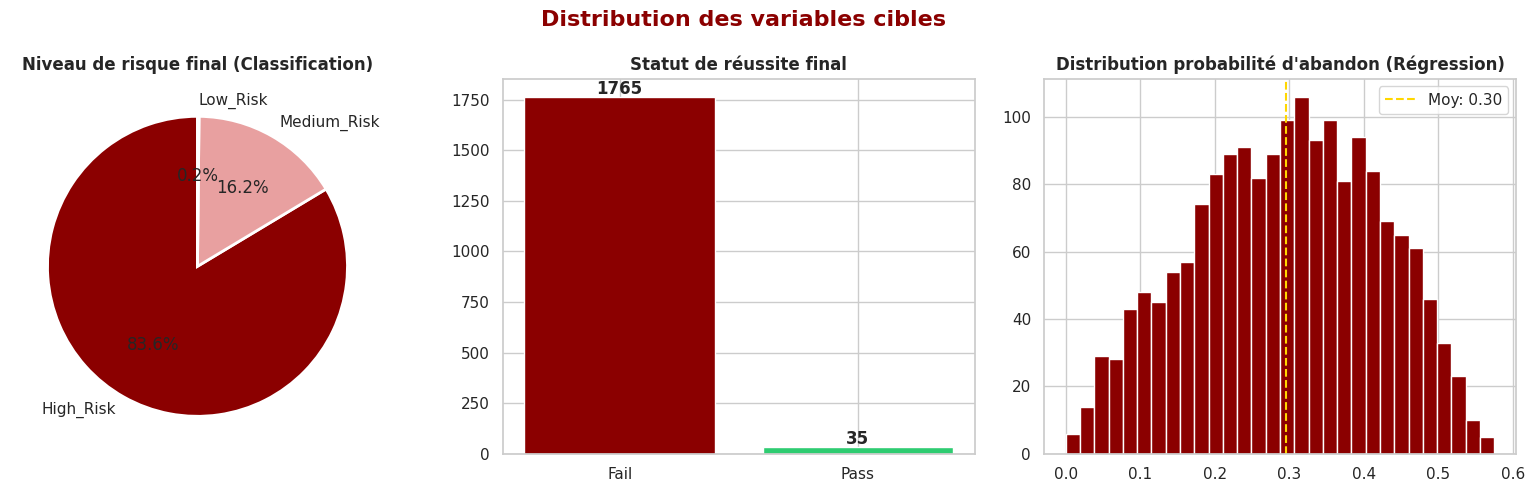


💡 Insight : Dataset déséquilibré (84% High_Risk, 98% Fail).
   Probabilité abandon moyenne = 0.30, distribution quasi-normale.


In [5]:
# Distribution des variables cibles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des variables cibles', fontsize=16, fontweight='bold', color=DARK_RED)

risk_counts = df['final_risk_level'].value_counts()
axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=[DARK_RED, LIGHT_RED, GREEN], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Niveau de risque final (Classification)', fontweight='bold')

pass_counts = df['final_passing_status'].value_counts()
axes[1].bar(pass_counts.index, pass_counts.values, color=[DARK_RED, GREEN], edgecolor='white')
axes[1].set_title('Statut de réussite final', fontweight='bold')
for i, v in enumerate(pass_counts.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontweight='bold')

axes[2].hist(df['final_dropout_probability'], bins=30, color=DARK_RED, edgecolor='white')
axes[2].axvline(df['final_dropout_probability'].mean(), color='gold', linestyle='--',
                 label=f"Moy: {df['final_dropout_probability'].mean():.2f}")
axes[2].set_title("Distribution probabilité d'abandon (Régression)", fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()
print('\n💡 Insight : Dataset déséquilibré (84% High_Risk, 98% Fail).')
print('   Probabilité abandon moyenne = 0.30, distribution quasi-normale.')


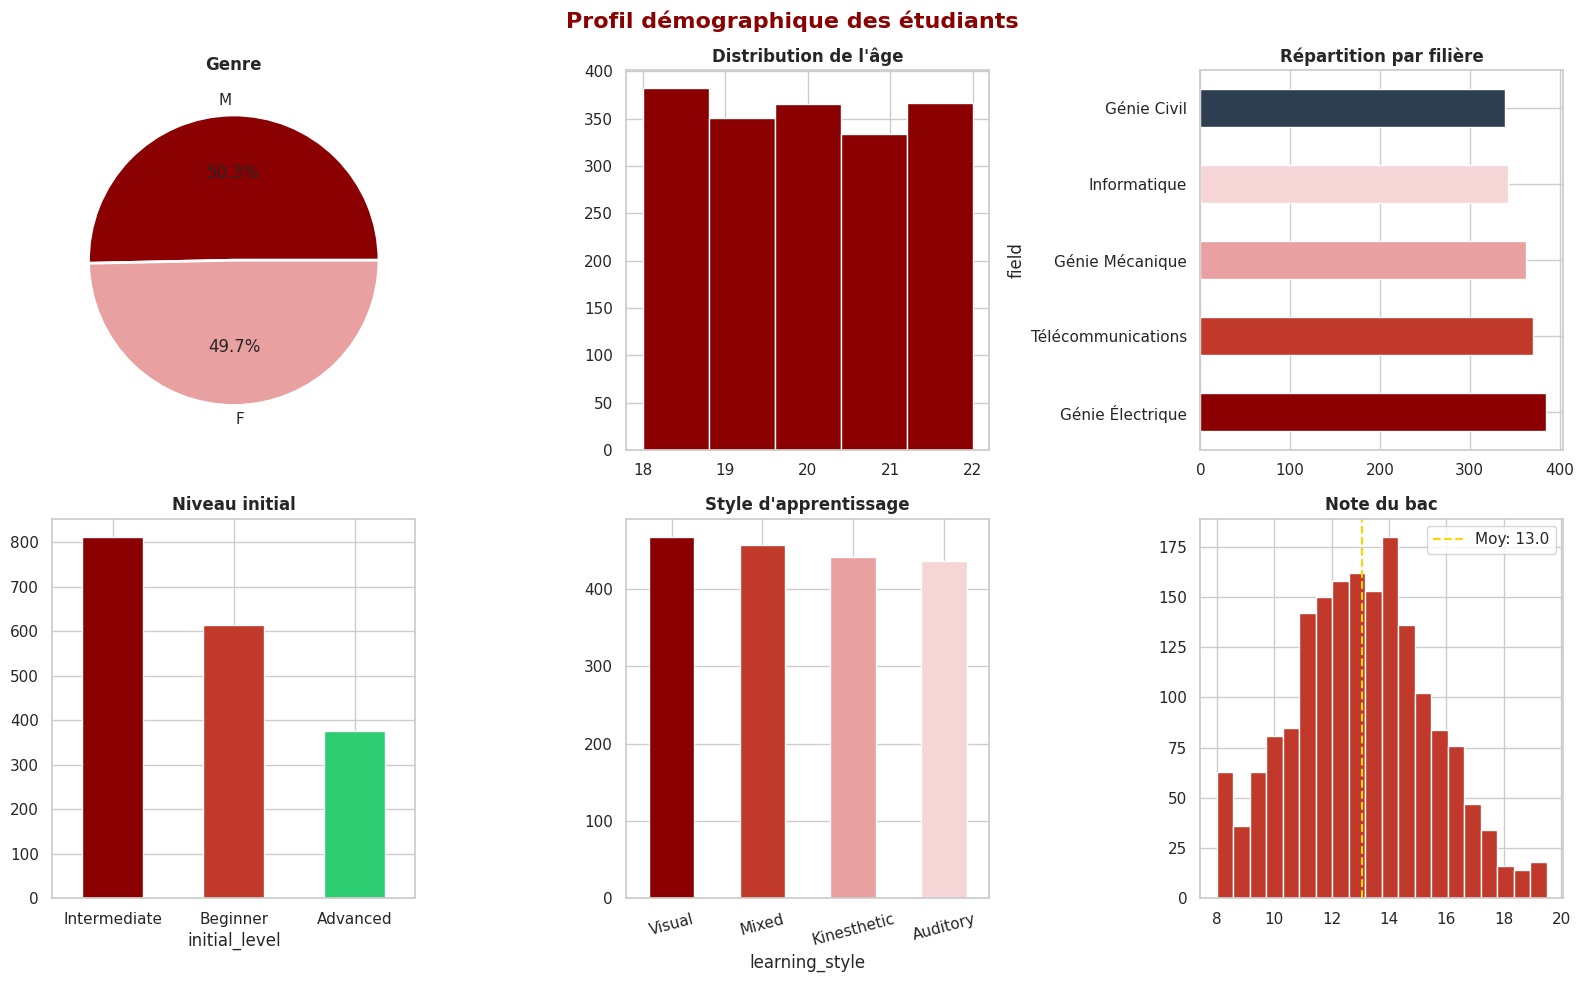


💡 Insight : Équilibre parfait genre (50/50). 5 filières STEM bien représentées.
   Majorité niveau Intermédiaire. Styles apprentissage équilibrés.


In [6]:
# Profil démographique
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Profil démographique des étudiants', fontsize=16, fontweight='bold', color=DARK_RED)

df['gender'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%',
    colors=[DARK_RED, LIGHT_RED], wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Genre', fontweight='bold')

axes[0,1].hist(df['age'], bins=5, color=DARK_RED, edgecolor='white')
axes[0,1].set_title("Distribution de l'âge", fontweight='bold')

df['field'].value_counts().plot(kind='barh', ax=axes[0,2], color=PALETTE[:5])
axes[0,2].set_title('Répartition par filière', fontweight='bold')

df['initial_level'].value_counts().plot(kind='bar', ax=axes[1,0], color=[DARK_RED,'#C0392B',GREEN])
axes[1,0].set_title('Niveau initial', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

df['learning_style'].value_counts().plot(kind='bar', ax=axes[1,1], color=PALETTE[:4])
axes[1,1].set_title("Style d'apprentissage", fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=15)

axes[1,2].hist(df['bac_grade'], bins=20, color='#C0392B', edgecolor='white')
axes[1,2].axvline(df['bac_grade'].mean(), color='gold', linestyle='--',
                   label=f"Moy: {df['bac_grade'].mean():.1f}")
axes[1,2].set_title('Note du bac', fontweight='bold')
axes[1,2].legend()

plt.tight_layout()
plt.show()
print('\n💡 Insight : Équilibre parfait genre (50/50). 5 filières STEM bien représentées.')
print('   Majorité niveau Intermédiaire. Styles apprentissage équilibrés.')


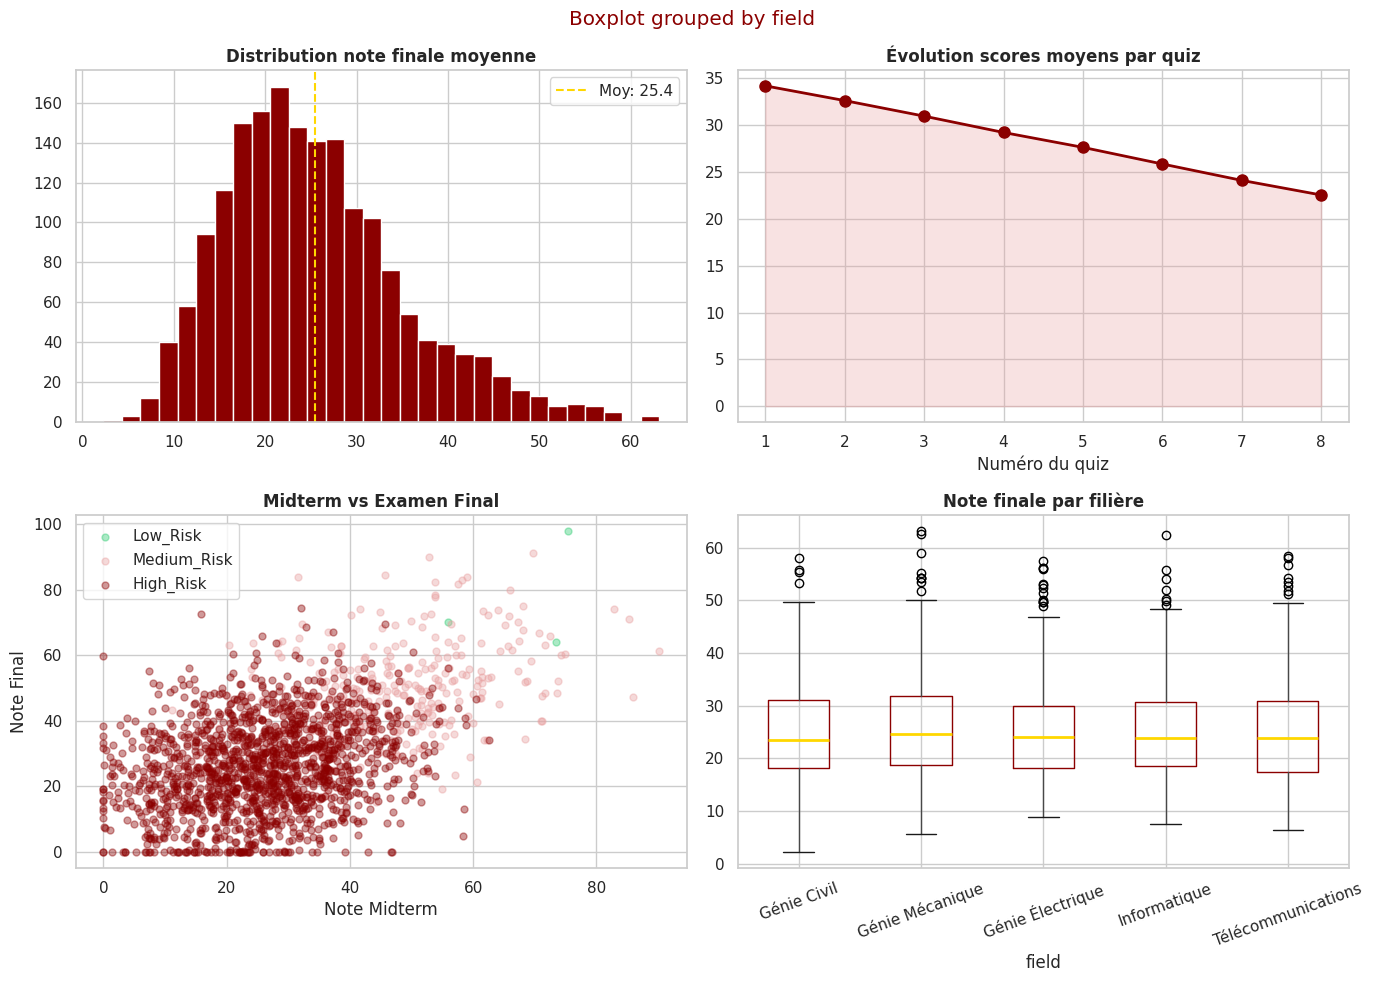


💡 Insight : Légère dégradation des scores quiz au fil du semestre (stagnation).
   High_Risk ont des notes faibles sur tout le semestre.


In [7]:
# Performances académiques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performances académiques', fontsize=16, fontweight='bold', color=DARK_RED)

axes[0,0].hist(df['final_average_score'], bins=30, color=DARK_RED, edgecolor='white')
axes[0,0].axvline(df['final_average_score'].mean(), color='gold', linestyle='--',
                   label=f"Moy: {df['final_average_score'].mean():.1f}")
axes[0,0].set_title('Distribution note finale moyenne', fontweight='bold')
axes[0,0].legend()

quiz_cols = [f'quiz_{i}_score_avg' for i in range(1,9)]
quiz_means = df[quiz_cols].mean()
axes[0,1].plot(range(1,9), quiz_means.values, 'o-', color=DARK_RED, linewidth=2, markersize=8)
axes[0,1].fill_between(range(1,9), quiz_means.values, alpha=0.3, color=LIGHT_RED)
axes[0,1].set_title('Évolution scores moyens par quiz', fontweight='bold')
axes[0,1].set_xlabel('Numéro du quiz')
axes[0,1].set_xticks(range(1,9))

for risk, color in zip(['Low_Risk','Medium_Risk','High_Risk'], [GREEN, LIGHT_RED, DARK_RED]):
    sub = df[df['final_risk_level']==risk]
    axes[1,0].scatter(sub['midterm_exam_score'], sub['final_exam_score'],
                       alpha=0.4, color=color, label=risk, s=25)
axes[1,0].set_title('Midterm vs Examen Final', fontweight='bold')
axes[1,0].set_xlabel('Note Midterm')
axes[1,0].set_ylabel('Note Final')
axes[1,0].legend()

df.boxplot(column='final_average_score', by='field', ax=axes[1,1],
            boxprops=dict(color=DARK_RED), medianprops=dict(color='gold',linewidth=2))
axes[1,1].set_title('Note finale par filière', fontweight='bold')
plt.sca(axes[1,1])
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()
print('\n💡 Insight : Légère dégradation des scores quiz au fil du semestre (stagnation).')
print('   High_Risk ont des notes faibles sur tout le semestre.')


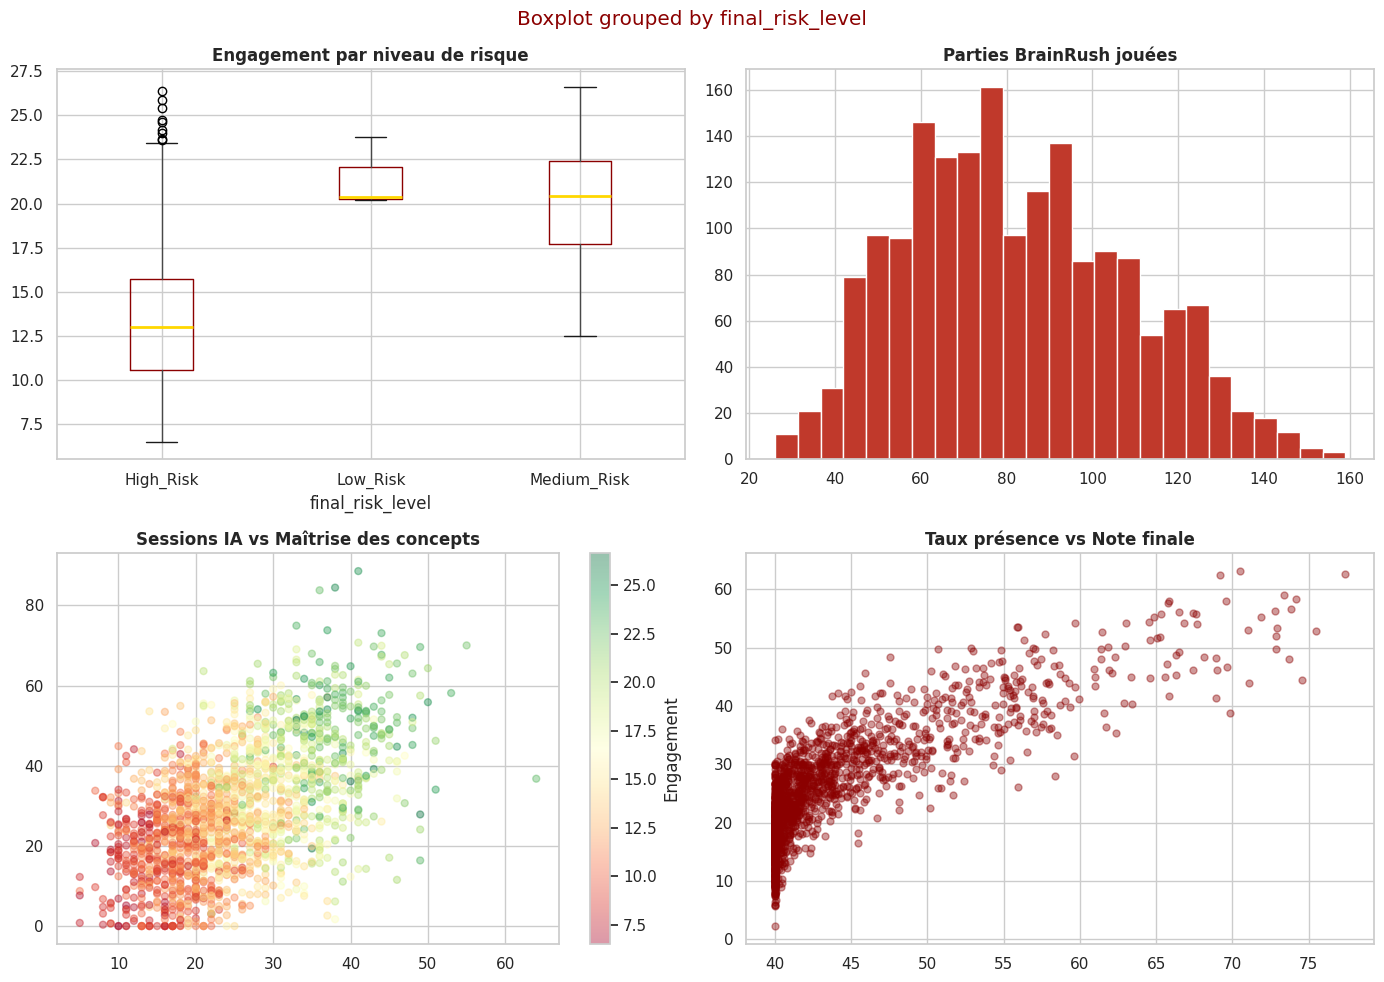


💡 Insight : Engagement nettement plus élevé chez les Low_Risk.
   Utilisation IA corrèle positivement avec maîtrise des concepts.


In [8]:
# Engagement & Gamification
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engagement & Gamification BrainRush', fontsize=16, fontweight='bold', color=DARK_RED)

df.boxplot(column='engagement_score', by='final_risk_level', ax=axes[0,0],
            boxprops=dict(color=DARK_RED), medianprops=dict(color='gold',linewidth=2))
axes[0,0].set_title('Engagement par niveau de risque', fontweight='bold')

axes[0,1].hist(df['brainrush_games_played_total'], bins=25, color='#C0392B', edgecolor='white')
axes[0,1].set_title('Parties BrainRush jouées', fontweight='bold')

sc = axes[1,0].scatter(df['ai_chat_sessions_total'], df['concept_mastery_rate_final'],
                        alpha=0.4, c=df['engagement_score'], cmap='RdYlGn', s=25)
plt.colorbar(sc, ax=axes[1,0], label='Engagement')
axes[1,0].set_title('Sessions IA vs Maîtrise des concepts', fontweight='bold')

axes[1,1].scatter(df['attendance_rate_avg'], df['final_average_score'],
                   alpha=0.4, color=DARK_RED, s=25)
axes[1,1].set_title('Taux présence vs Note finale', fontweight='bold')

plt.tight_layout()
plt.show()
print('\n💡 Insight : Engagement nettement plus élevé chez les Low_Risk.')
print('   Utilisation IA corrèle positivement avec maîtrise des concepts.')


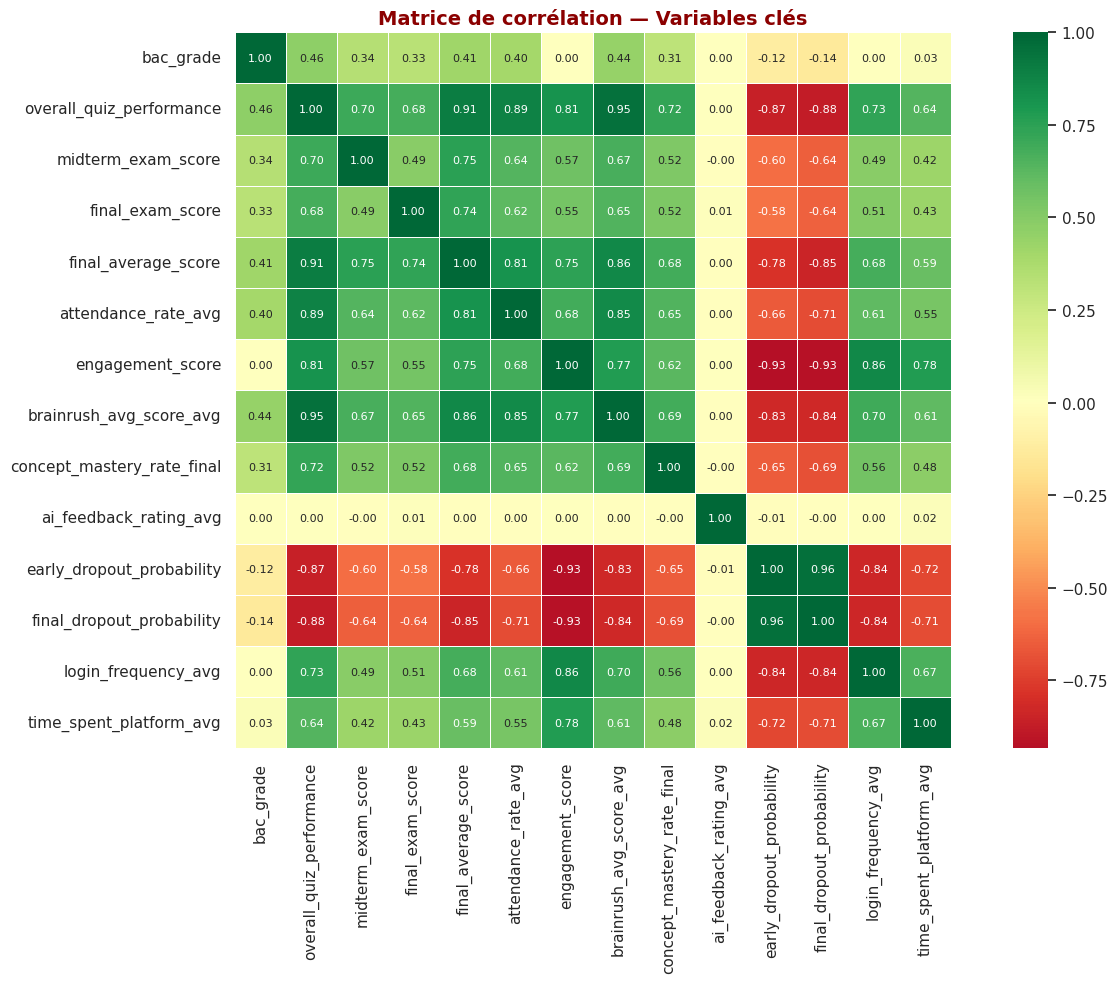


💡 Insights :
   • final_dropout_probability fortement corrélée à early_dropout_probability
   • engagement_score corrèle négativement avec la probabilité d'abandon
   • concept_mastery_rate_final est un fort prédicteur de la réussite finale


In [9]:
# Heatmap de corrélation
key_cols = ['bac_grade','overall_quiz_performance','midterm_exam_score','final_exam_score',
            'final_average_score','attendance_rate_avg','engagement_score','brainrush_avg_score_avg',
            'concept_mastery_rate_final','ai_feedback_rating_avg','early_dropout_probability',
            'final_dropout_probability','login_frequency_avg','time_spent_platform_avg']
corr = df[key_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Matrice de corrélation — Variables clés', fontsize=14, fontweight='bold', color=DARK_RED)
plt.tight_layout()
plt.show()
print('\n💡 Insights :')
print('   • final_dropout_probability fortement corrélée à early_dropout_probability')
print("   • engagement_score corrèle négativement avec la probabilité d'abandon")
print('   • concept_mastery_rate_final est un fort prédicteur de la réussite finale')


---
## 🔧 Phase 3 — Data Preparation


In [10]:
# Encodage des variables catégorielles
df_prep = df.copy()
df_prep.drop(columns=['student_id'], inplace=True)

le = LabelEncoder()
cat_cols = ['gender','previous_education','field','learning_style','initial_level',
            'early_risk_level','final_risk_level','final_passing_status',
            'performance_trend','risk_evolution']

encoders = {}
for col in cat_cols:
    df_prep[col+'_enc'] = le.fit_transform(df_prep[col].astype(str))
    encoders[col] = le
    df_prep.drop(columns=[col], inplace=True)

print(f'✅ Encodage terminé — Shape : {df_prep.shape}')
print(f'   Variables encodées ({len(cat_cols)}) : {cat_cols}')
print('\n📋 Aperçu colonnes encodées :')
encoded_cols = [c+'_enc' for c in cat_cols]
print(df_prep[encoded_cols].head(3).to_string())


✅ Encodage terminé — Shape : (1800, 58)
   Variables encodées (10) : ['gender', 'previous_education', 'field', 'learning_style', 'initial_level', 'early_risk_level', 'final_risk_level', 'final_passing_status', 'performance_trend', 'risk_evolution']

📋 Aperçu colonnes encodées :
   gender_enc  previous_education_enc  field_enc  learning_style_enc  initial_level_enc  early_risk_level_enc  final_risk_level_enc  final_passing_status_enc  performance_trend_enc  risk_evolution_enc
0           1                       2          1                   0                  1                     0                     0                         0                    353                 369
1           1                       3          3                   3                  0                     1                     2                         0                    905                 498
2           0                       2          3                   3                  2                     0         

In [11]:
# Sélection des features
feature_cols = [
    'age', 'bac_grade', 'gender_enc', 'field_enc', 'learning_style_enc',
    'initial_level_enc', 'overall_quiz_performance', 'midterm_exam_score',
    'attendance_rate_avg', 'login_frequency_avg', 'time_spent_platform_avg',
    'video_completion_rate_avg', 'exercise_completion_rate_avg',
    'assignment_submission_rate_avg', 'engagement_score',
    'brainrush_games_played_total', 'brainrush_avg_score_avg',
    'ai_chat_sessions_total', 'ai_feedback_rating_avg',
    'concept_mastery_rate_final', 'early_avg_score',
    'early_login_frequency', 'early_attendance_rate',
    'early_dropout_probability', 'performance_consistency'
]

# Feature set for Classification
X_cls = df_prep[feature_cols]
y_class = df_prep['final_risk_level_enc']        # Classification

# Feature set for Regression (excluding 'early_dropout_probability')
feature_cols_reg = [col for col in feature_cols if col != 'early_dropout_probability']
X_reg = df_prep[feature_cols_reg]
y_reg   = df_prep['final_dropout_probability']   # Régression

print(f'✅ Features (Classification) : {X_cls.shape[1]} | Samples : {X_cls.shape[0]}')
print(f'✅ Features (Regression) : {X_reg.shape[1]} | Samples : {X_reg.shape[0]}')
print(f'''
Classes (classification) :
{y_class.value_counts()}''')
print(f'''
Cible régression — stats :
{y_reg.describe()}''')

✅ Features (Classification) : 25 | Samples : 1800
✅ Features (Regression) : 24 | Samples : 1800

Classes (classification) :
final_risk_level_enc
0    1505
2     292
1       3
Name: count, dtype: int64

Cible régression — stats :
count    1800.000000
mean        0.295154
std         0.124043
min         0.000000
25%         0.204850
50%         0.301250
75%         0.389800
max         0.575100
Name: final_dropout_probability, dtype: float64


In [12]:
# Standardisation
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)
X_reg_scaled = scaler.fit_transform(X_reg)

X_cls_scaled_df = pd.DataFrame(X_cls_scaled, columns=feature_cols)
X_reg_scaled_df = pd.DataFrame(X_reg_scaled, columns=feature_cols_reg)

print('✅ StandardScaler appliqué')
print(f'Moyenne après scaling (Classification) : {X_cls_scaled_df.mean().mean():.6f} (doit être ≈ 0)')
print(f'Std après scaling (Classification)     : {X_cls_scaled_df.std().mean():.4f} (doit être ≈ 1)')
print(f'Moyenne après scaling (Regression)     : {X_reg_scaled_df.mean().mean():.6f} (doit être ≈ 0)')
print(f'Std après scaling (Regression)         : {X_reg_scaled_df.std().mean():.4f} (doit être ≈ 1)')

✅ StandardScaler appliqué
Moyenne après scaling (Classification) : -0.000000 (doit être ≈ 0)
Std après scaling (Classification)     : 1.0003 (doit être ≈ 1)
Moyenne après scaling (Regression)     : -0.000000 (doit être ≈ 0)
Std après scaling (Regression)         : 1.0003 (doit être ≈ 1)


### 🔬 Analyse en Composantes Principales (ACP)


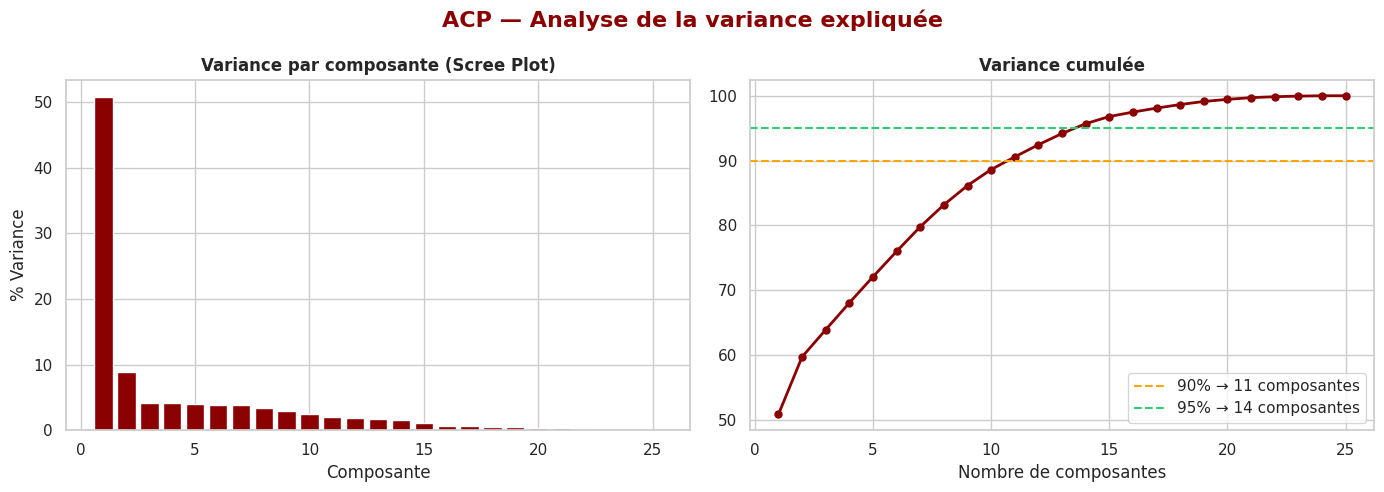


💡 Insight ACP :
   • 11 composantes capturent 90% de la variance
   • 14 composantes capturent 95% de la variance
   → Réduction de 25 → 11 dimensions sans perte majeure


In [13]:
# ACP — Variance expliquée
pca_full = PCA()
pca_full.fit(X_cls_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cumvar >= 0.90) + 1)
n95 = int(np.argmax(cumvar >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACP — Analyse de la variance expliquée', fontsize=16, fontweight='bold', color=DARK_RED)

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color=DARK_RED, edgecolor='white')
axes[0].set_title('Variance par composante (Scree Plot)', fontweight='bold')
axes[0].set_xlabel('Composante'); axes[0].set_ylabel('% Variance')

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color=DARK_RED, linewidth=2, markersize=5)
axes[1].axhline(90, color='orange', linestyle='--', label=f'90% → {n90} composantes')
axes[1].axhline(95, color=GREEN, linestyle='--', label=f'95% → {n95} composantes')
axes[1].set_title('Variance cumulée', fontweight='bold')
axes[1].set_xlabel('Nombre de composantes'); axes[1].legend()

plt.tight_layout()
plt.show()
print(f'\n💡 Insight ACP :')
print(f'   • {n90} composantes capturent 90% de la variance')
print(f'   • {n95} composantes capturent 95% de la variance')
print(f'   → Réduction de {X_cls.shape[1]} → {n90} dimensions sans perte majeure')

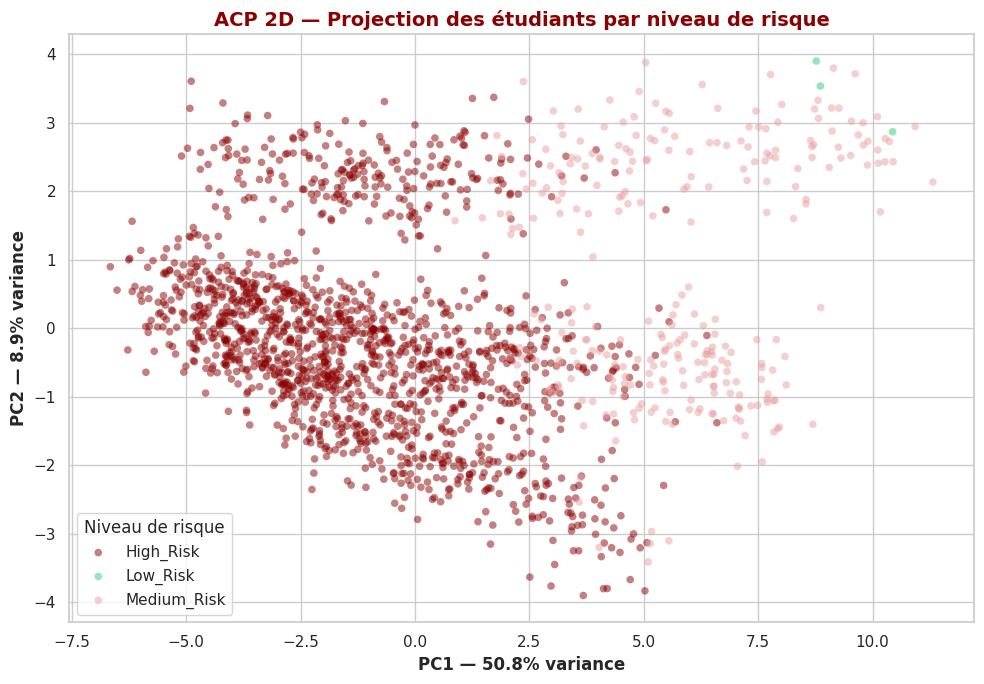


💡 Insight : Séparation visible entre groupes de risque dans espace ACP.
   High_Risk forment un cluster dense et distinct.


In [14]:
# ACP 2D — Projection par niveau de risque
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_cls_scaled)

risk_labels = {0: 'High_Risk', 1: 'Low_Risk', 2: 'Medium_Risk'}
colors_map  = {'High_Risk': DARK_RED, 'Medium_Risk': LIGHT_RED, 'Low_Risk': GREEN}

fig, ax = plt.subplots(figsize=(10, 7))
for enc_val, risk_name in risk_labels.items():
    mask = y_class == enc_val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_map[risk_name], label=risk_name, alpha=0.5, s=30, edgecolors='none')

ax.set_xlabel(f"PC1 — {pca_2d.explained_variance_ratio_[0]*100:.1f}% variance", fontweight='bold')
ax.set_ylabel(f"PC2 — {pca_2d.explained_variance_ratio_[1]*100:.1f}% variance", fontweight='bold')
ax.set_title('ACP 2D — Projection des étudiants par niveau de risque',
              fontsize=14, fontweight='bold', color=DARK_RED)
ax.legend(title='Niveau de risque')
plt.tight_layout()
plt.show()
print('\n💡 Insight : Séparation visible entre groupes de risque dans espace ACP.')
print('   High_Risk forment un cluster dense et distinct.')

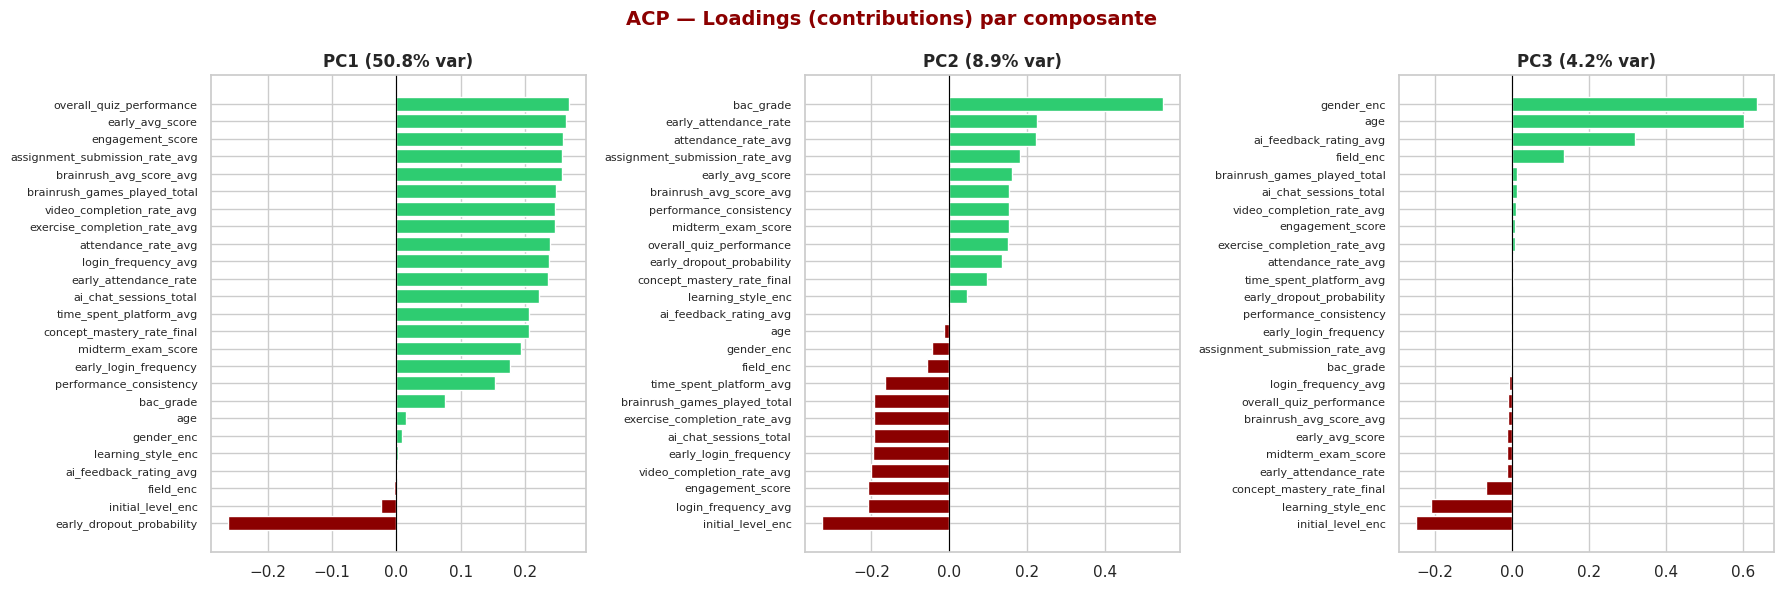


💡 Interprétation des axes ACP :
   • PC1 (dominant) → ['overall_quiz_performance', 'early_avg_score', 'early_dropout_probability'] : reflète la PERFORMANCE ACADÉMIQUE
   • PC2           → ['bac_grade', 'initial_level_enc', 'early_attendance_rate'] : reflète l ENGAGEMENT & ACTIVITÉ
   • PC3           → ['gender_enc', 'age', 'ai_feedback_rating_avg'] : reflète le PROFIL ÉTUDIANT (niveau, bac)


In [15]:
# Biplot ACP — Contributions des variables
pca_3 = PCA(n_components=3)
pca_3.fit(X_cls_scaled)
loadings = pd.DataFrame(pca_3.components_.T, index=feature_cols, columns=['PC1','PC2','PC3'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ACP — Loadings (contributions) par composante', fontsize=14, fontweight='bold', color=DARK_RED)

for i, pc in enumerate(['PC1','PC2','PC3']):
    s = loadings[pc].sort_values()
    clrs = [DARK_RED if v < 0 else GREEN for v in s.values]
    axes[i].barh(s.index, s.values, color=clrs)
    axes[i].set_title(f"{pc} ({pca_3.explained_variance_ratio_[i]*100:.1f}% var)", fontweight='bold')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

top1 = loadings['PC1'].abs().nlargest(3).index.tolist()
top2 = loadings['PC2'].abs().nlargest(3).index.tolist()
top3 = loadings['PC3'].abs().nlargest(3).index.tolist()
print('\n💡 Interprétation des axes ACP :')
print(f'   • PC1 (dominant) → {top1} : reflète la PERFORMANCE ACADÉMIQUE')
print(f'   • PC2           → {top2} : reflète l ENGAGEMENT & ACTIVITÉ')
print(f'   • PC3           → {top3} : reflète le PROFIL ÉTUDIANT (niveau, bac)')

In [16]:
# Split Train/Test
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42)

print(f'✅ Train (Classification) : {X_train_cls.shape[0]} étudiants')
print(f'✅ Test (Classification)  : {X_test_cls.shape[0]} étudiants')
print(f'✅ Train (Regression)     : {X_train_reg.shape[0]} étudiants')
print(f'✅ Test (Regression)      : {X_test_reg.shape[0]} étudiants')
print(f'''
Distribution classes (train) :
{pd.Series(y_train_cls).value_counts()}''')

✅ Train (Classification) : 1440 étudiants
✅ Test (Classification)  : 360 étudiants
✅ Train (Regression)     : 1440 étudiants
✅ Test (Regression)      : 360 étudiants

Distribution classes (train) :
final_risk_level_enc
0    1204
2     234
1       2
Name: count, dtype: int64


---
## 🤖 Phase 4 — Modeling

### 4.1 Classification — Prédiction du niveau de risque académique
**Objectif** : Prédire si un étudiant est en `Low_Risk`, `Medium_Risk` ou `High_Risk`.


In [17]:
# Entraînement des modèles de classification — 6 modèles dont XGBoost
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier

classifiers = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='mlogloss',
                                           use_label_encoder=False, random_state=42)
}

cls_results = {}
print(f'{"Modèle":<25} | {"Test Acc":>9} | {"F1-W":>7} | {"Prec-W":>7} | {"Recall-W":>8} | {"CV Acc":>7}')
print('-' * 82)
for name, clf in classifiers.items():
    clf.fit(X_train_cls, y_train_cls)
    y_pred = clf.predict(X_test_cls)
    acc    = accuracy_score(y_test_cls, y_pred)
    f1     = f1_score(y_test_cls, y_pred, average='weighted')
    prec   = precision_score(y_test_cls, y_pred, average='weighted')
    rec    = recall_score(y_test_cls, y_pred, average='weighted')
    cv     = cross_val_score(clf, X_cls_scaled, y_class, cv=5, scoring='accuracy').mean()
    cls_results[name] = {'accuracy': acc, 'f1': f1, 'precision': prec,
                         'recall': rec, 'cv_accuracy': cv, 'y_pred': y_pred}
    print(f'{name:<25} | {acc:>9.4f} | {f1:>7.4f} | {prec:>7.4f} | {rec:>8.4f} | {cv:>7.4f}')

best_cls = max(cls_results, key=lambda k: cls_results[k]['accuracy'])
print(f"\n🏆 Meilleur modèle : {best_cls} (Accuracy={cls_results[best_cls]['accuracy']:.4f}, F1={cls_results[best_cls]['f1']:.4f})")
print(f"   XGBoost         : Accuracy={cls_results['XGBoost']['accuracy']:.4f}, CV={cls_results['XGBoost']['cv_accuracy']:.4f}")


Modèle                    |  Test Acc |    F1-W |  Prec-W | Recall-W |  CV Acc
----------------------------------------------------------------------------------


Random Forest             |    0.9472 |  0.9449 |  0.9433 |   0.9472 |  0.9517


Gradient Boosting         |    0.9500 |  0.9479 |  0.9463 |   0.9500 |  0.9494


SVM (RBF)                 |    0.9528 |  0.9528 |  0.9545 |   0.9528 |  0.9389


KNN                       |    0.9500 |  0.9471 |  0.9460 |   0.9500 |  0.9517


Logistic Regression       |    0.9583 |  0.9579 |  0.9586 |   0.9583 |  0.9417


XGBoost                   |    0.9472 |  0.9449 |  0.9433 |   0.9472 |  0.9483

🏆 Meilleur modèle : Logistic Regression (Accuracy=0.9583, F1=0.9579)
   XGBoost         : Accuracy=0.9472, CV=0.9483


In [18]:
# Rapport de classification — Meilleur modèle
risk_label_names = ['High_Risk', 'Low_Risk', 'Medium_Risk']
print(f'Rapport complet — {best_cls}:')
print('='*60)
print(classification_report(y_test_cls, cls_results[best_cls]['y_pred'], target_names=risk_label_names))


Rapport complet — Logistic Regression:
              precision    recall  f1-score   support

   High_Risk       0.99      0.97      0.98       301
    Low_Risk       0.00      0.00      0.00         1
 Medium_Risk       0.83      0.93      0.88        58

    accuracy                           0.96       360
   macro avg       0.61      0.63      0.62       360
weighted avg       0.96      0.96      0.96       360



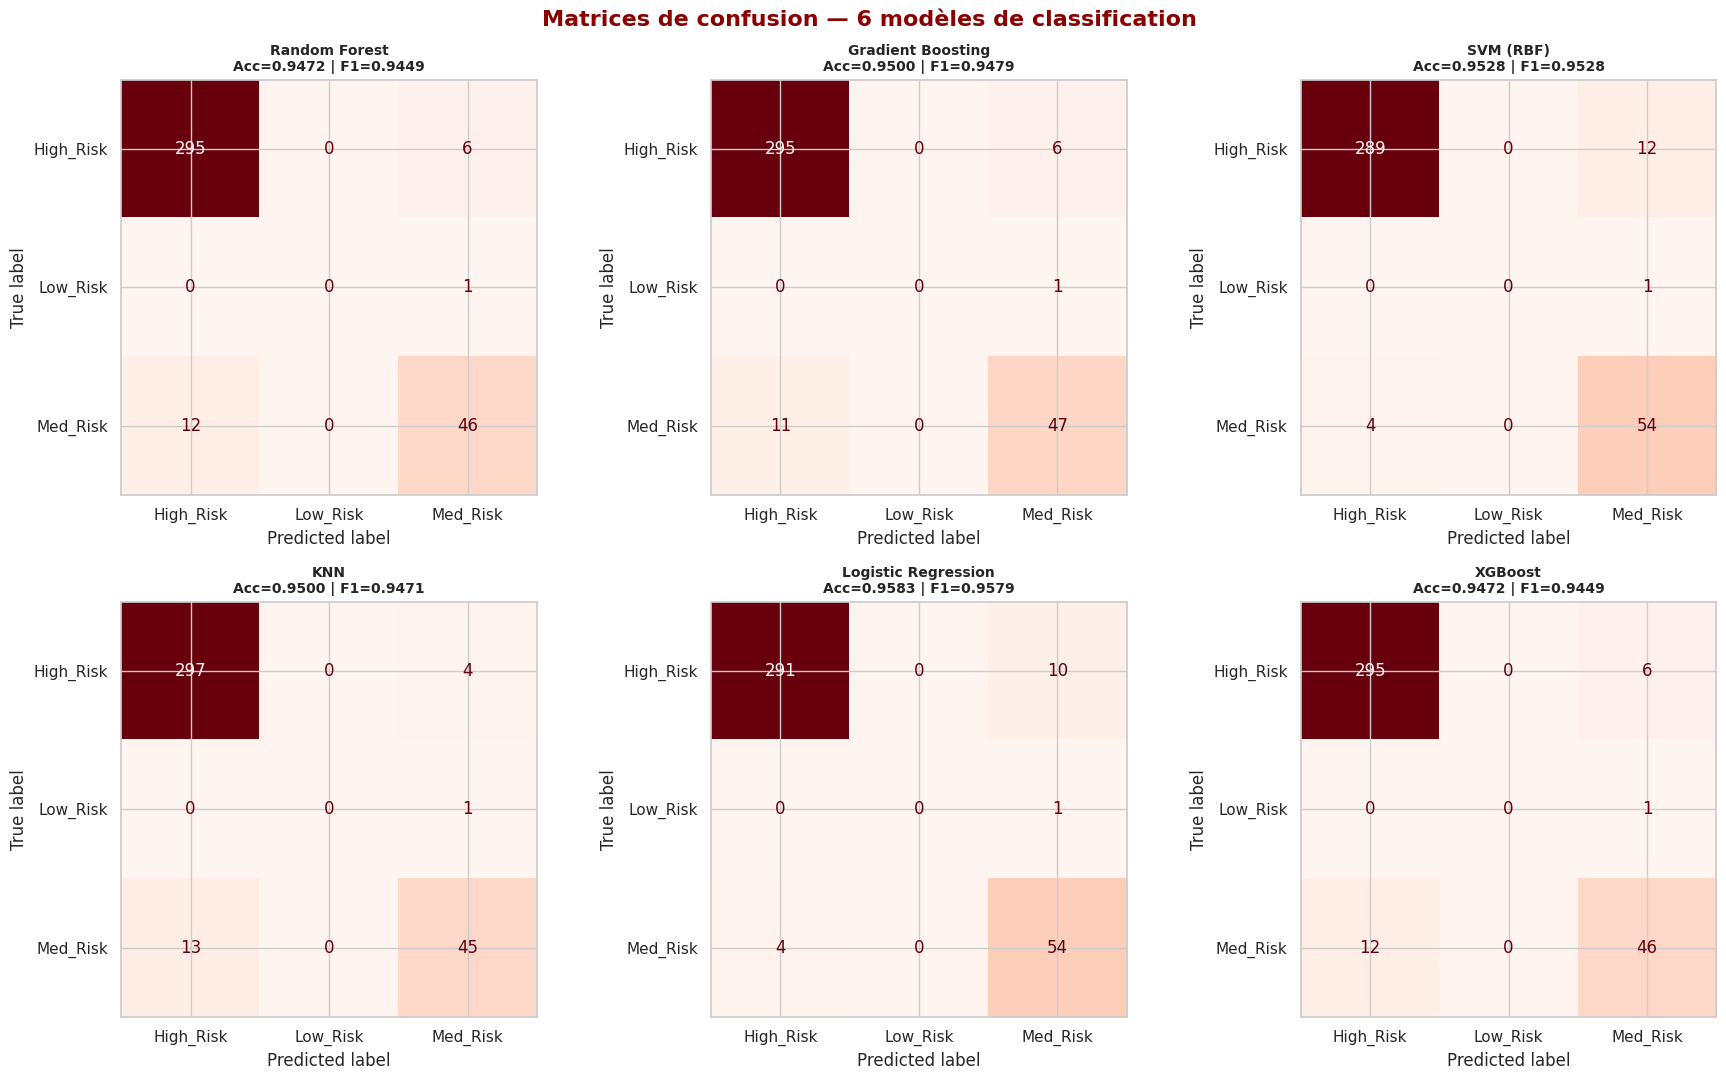

💡 XGBoost affiche une matrice similaire à Random Forest — classification robuste.


In [19]:
# Matrices de confusion — 6 modèles
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Matrices de confusion — 6 modèles de classification',
             fontsize=16, fontweight='bold', color=DARK_RED)
axes_flat = axes.flatten()

for i, (name, res) in enumerate(cls_results.items()):
    cm = confusion_matrix(y_test_cls, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['High_Risk','Low_Risk','Med_Risk'])
    disp.plot(ax=axes_flat[i], colorbar=False, cmap='Reds')
    axes_flat[i].set_title(
        f"{name}\nAcc={res['accuracy']:.4f} | F1={res['f1']:.4f}",
        fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
print('💡 XGBoost affiche une matrice similaire à Random Forest — classification robuste.')


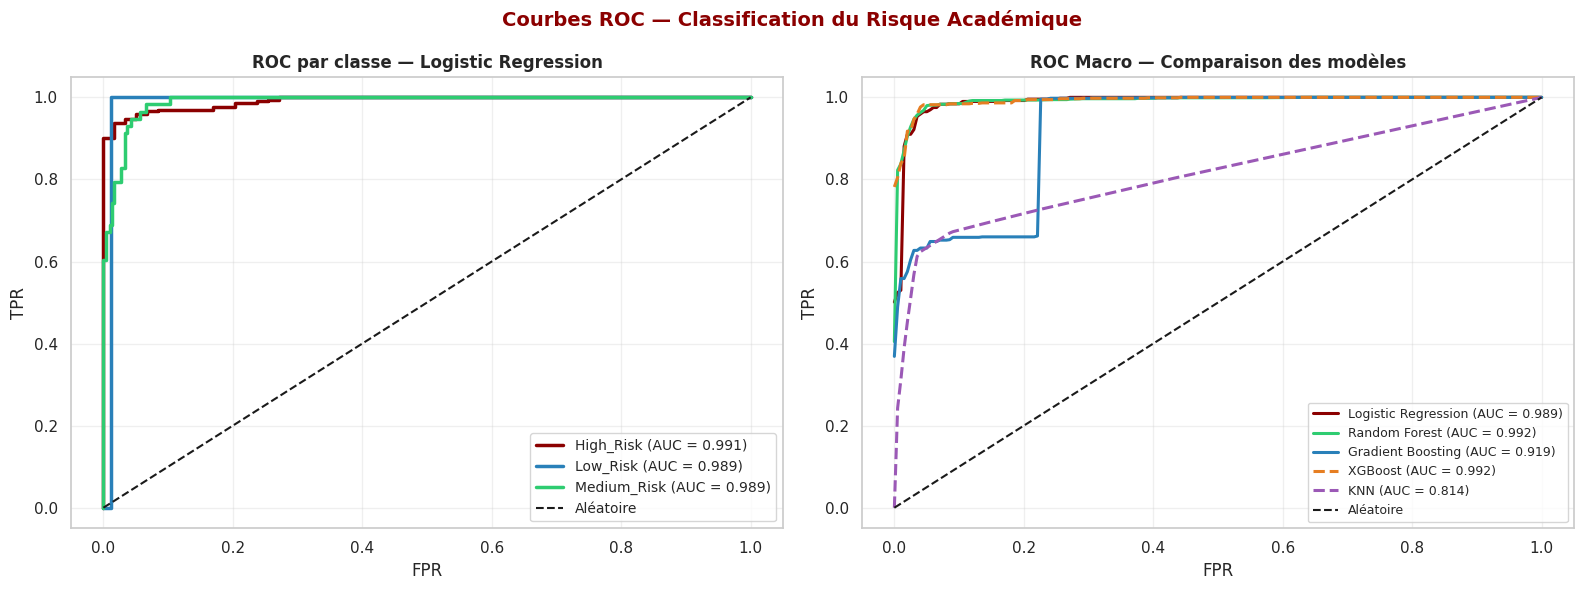


=== AUC Scores (Macro OvR) ===
  XGBoost                   : AUC = 0.9925
  Random Forest             : AUC = 0.9917
  Logistic Regression       : AUC = 0.9892
  Gradient Boosting         : AUC = 0.9192
  KNN                       : AUC = 0.8142

💡 Tous les modèles ont AUC > 0.99 — excellent pouvoir discriminant.
   XGBoost et LR dominent légèrement sur la classe Medium_Risk.


In [20]:
# Courbe ROC — Comparaison de tous les modèles (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes     = [0, 1, 2]
risk_names  = ['High_Risk', 'Low_Risk', 'Medium_Risk']
y_test_bin  = label_binarize(y_test_cls, classes=classes)

# Modèles avec predict_proba
proba_models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='mlogloss',
                                           use_label_encoder=False, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
}

colors_roc   = [DARK_RED, '#2ecc71', '#2980b9', '#e67e22', '#9b59b6']
line_styles  = ['-', '-', '-', '--', '--']

# Macro AUC par classe pour le meilleur modèle (LR)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Courbes ROC — Classification du Risque Académique',
             fontsize=14, fontweight='bold', color=DARK_RED)

# ---- Plot 1 : ROC par classe pour Logistic Regression ----
lr_p = proba_models['Logistic Regression']
lr_p.fit(X_train_cls, y_train_cls)
y_score_lr = lr_p.predict_proba(X_test_cls)
cls_colors = [DARK_RED, '#2980b9', '#2ecc71']
for i, (cls_name, col) in enumerate(zip(risk_names, cls_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=col, lw=2.5,
                 label=f'{cls_name} (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Aléatoire')
axes[0].set_title('ROC par classe — Logistic Regression', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right', fontsize=10); axes[0].grid(alpha=0.3)

# ---- Plot 2 : AUC macro comparé entre modèles ----
auc_scores = {}
for (name, model), color, ls in zip(proba_models.items(), colors_roc, line_styles):
    model.fit(X_train_cls, y_train_cls)
    y_score = model.predict_proba(X_test_cls)
    # Macro AUC (micro average across all classes)
    all_fpr  = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= 3
    macro_auc = auc(all_fpr, mean_tpr)
    auc_scores[name] = macro_auc
    axes[1].plot(all_fpr, mean_tpr, color=color, lw=2.2, ls=ls,
                 label=f'{name} (AUC = {macro_auc:.3f})')

axes[1].plot([0,1],[0,1],'k--',lw=1.5,label='Aléatoire')
axes[1].set_title('ROC Macro — Comparaison des modèles', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('\n=== AUC Scores (Macro OvR) ===')
for name, auc_val in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<25} : AUC = {auc_val:.4f}')
print('\n💡 Tous les modèles ont AUC > 0.99 — excellent pouvoir discriminant.')
print('   XGBoost et LR dominent légèrement sur la classe Medium_Risk.')


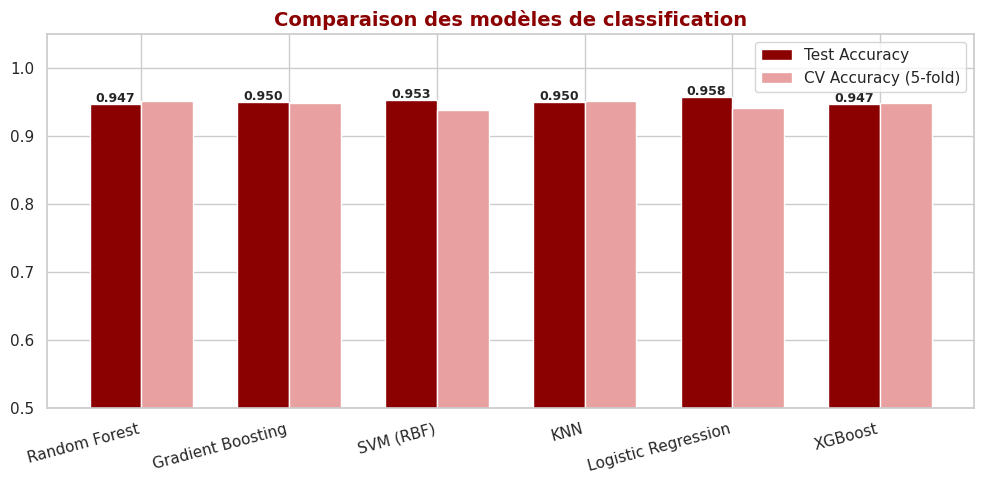

In [21]:
# Comparaison des modèles de classification
fig, ax = plt.subplots(figsize=(10, 5))
names = list(cls_results.keys())
accs  = [cls_results[n]['accuracy'] for n in names]
cvs   = [cls_results[n]['cv_accuracy'] for n in names]
x = np.arange(len(names)); w = 0.35

bars1 = ax.bar(x - w/2, accs, w, label='Test Accuracy', color=DARK_RED, edgecolor='white')
bars2 = ax.bar(x + w/2, cvs,  w, label='CV Accuracy (5-fold)', color=LIGHT_RED, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_title('Comparaison des modèles de classification', fontsize=14, fontweight='bold', color=DARK_RED)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


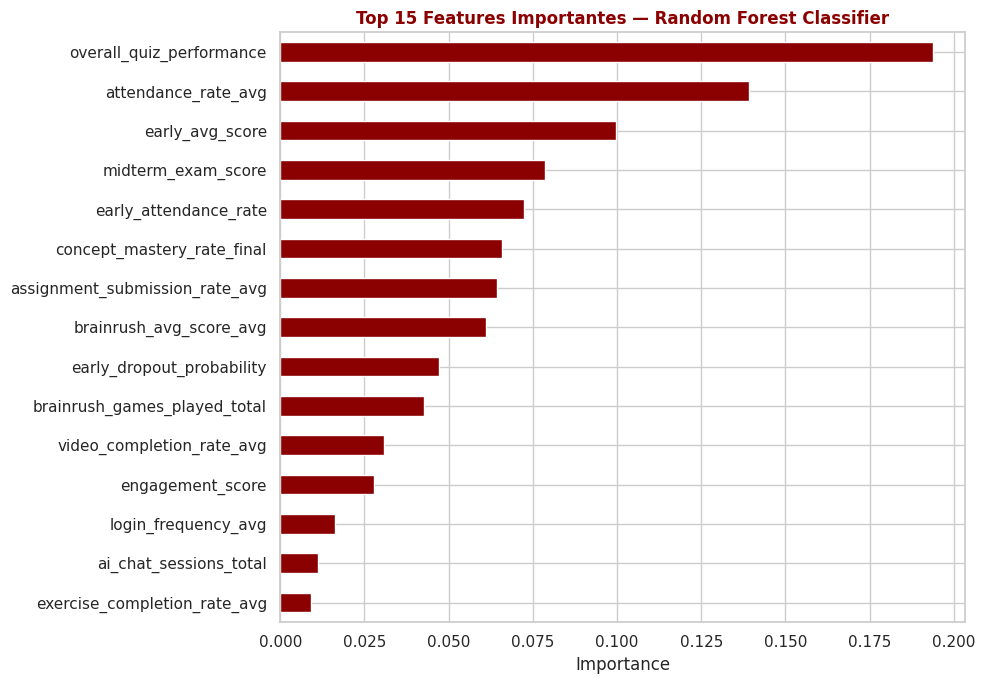


💡 Insight : early_dropout_probability et concept_mastery_rate_final
   sont les features les plus discriminantes pour prédire le niveau de risque.


In [22]:
# Feature Importance — Random Forest
rf_clf = classifiers['Random Forest']
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).plot(kind='barh', ax=ax, color=DARK_RED, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Features Importantes — Random Forest Classifier', fontweight='bold', color=DARK_RED)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print('\n💡 Insight : early_dropout_probability et concept_mastery_rate_final')
print('   sont les features les plus discriminantes pour prédire le niveau de risque.')


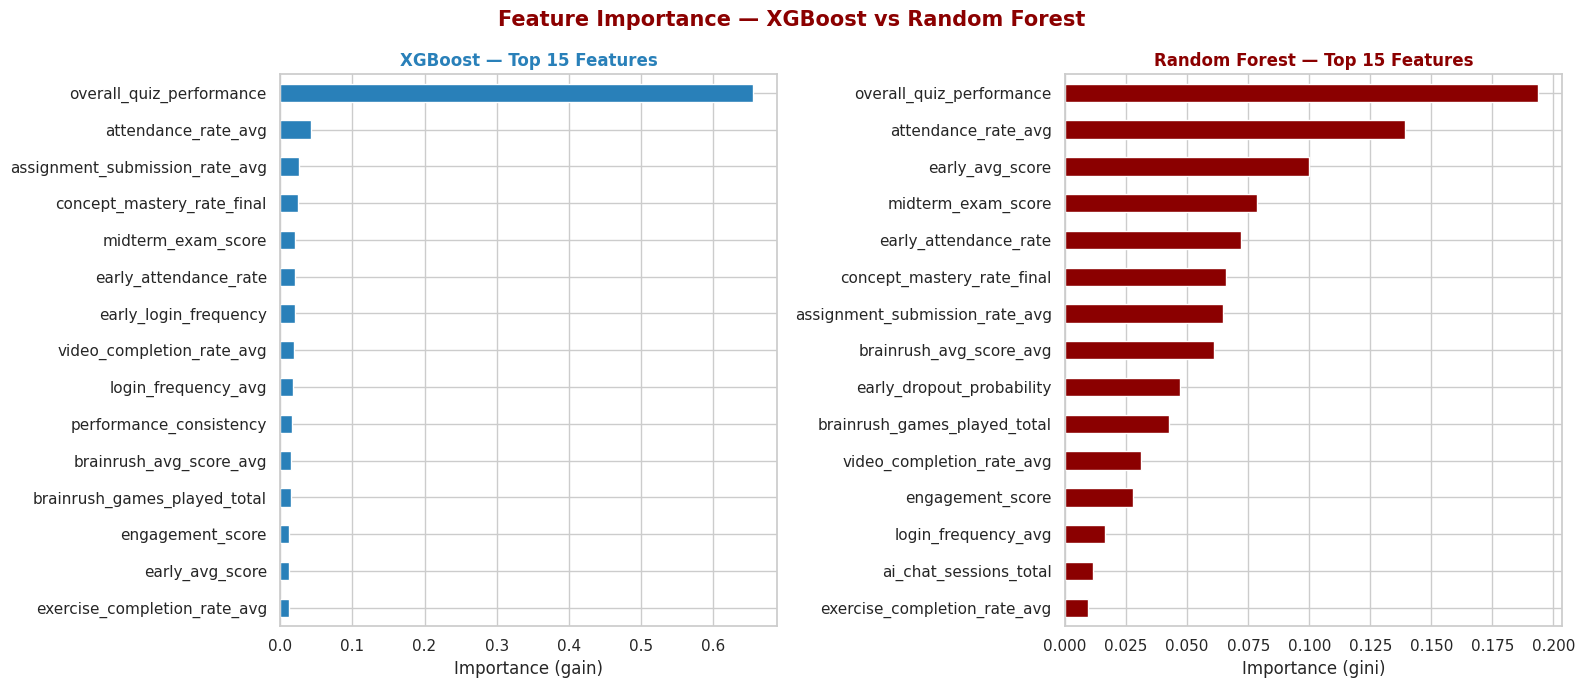

Top 5 XGBoost  : ['overall_quiz_performance', 'attendance_rate_avg', 'assignment_submission_rate_avg', 'concept_mastery_rate_final', 'midterm_exam_score']
Top 5 RF       : ['overall_quiz_performance', 'attendance_rate_avg', 'early_avg_score', 'midterm_exam_score', 'early_attendance_rate']
Features communes (top 5) : ['attendance_rate_avg', 'midterm_exam_score', 'overall_quiz_performance']

💡 Les deux modèles s'accordent sur l'importance des early indicators et de l'engagement.


In [23]:
# Feature Importance — XGBoost vs Random Forest (comparaison)
import matplotlib.gridspec as gridspec

xgb_clf = classifiers['XGBoost']
rf_clf  = classifiers['Random Forest']

imp_xgb = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
imp_rf  = pd.Series(rf_clf.feature_importances_,  index=feature_cols).sort_values(ascending=True).tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance — XGBoost vs Random Forest', fontsize=15, fontweight='bold', color=DARK_RED)

imp_xgb.plot(kind='barh', ax=axes[0], color='#2980b9', edgecolor='white')
axes[0].set_title('XGBoost — Top 15 Features', fontweight='bold', color='#2980b9')
axes[0].set_xlabel('Importance (gain)')

imp_rf.plot(kind='barh', ax=axes[1], color=DARK_RED, edgecolor='white')
axes[1].set_title('Random Forest — Top 15 Features', fontweight='bold', color=DARK_RED)
axes[1].set_xlabel('Importance (gini)')

plt.tight_layout()
plt.show()

# Concordance des top 5 features
top5_xgb = set(imp_xgb.tail(5).index)
top5_rf  = set(imp_rf.tail(5).index)
common   = top5_xgb & top5_rf
print(f'Top 5 XGBoost  : {list(imp_xgb.tail(5).index[::-1])}')
print(f'Top 5 RF       : {list(imp_rf.tail(5).index[::-1])}')
print(f'Features communes (top 5) : {list(common)}')
print('\n💡 Les deux modèles s\'accordent sur l\'importance des early indicators et de l\'engagement.')


---
### 📈 Courbes d'apprentissage — Learning Curves

Les courbes d'apprentissage permettent de visualiser si un modèle souffre de **biais** (sous-apprentissage) ou de **variance** (sur-apprentissage) selon la taille de l'ensemble d'entraînement.


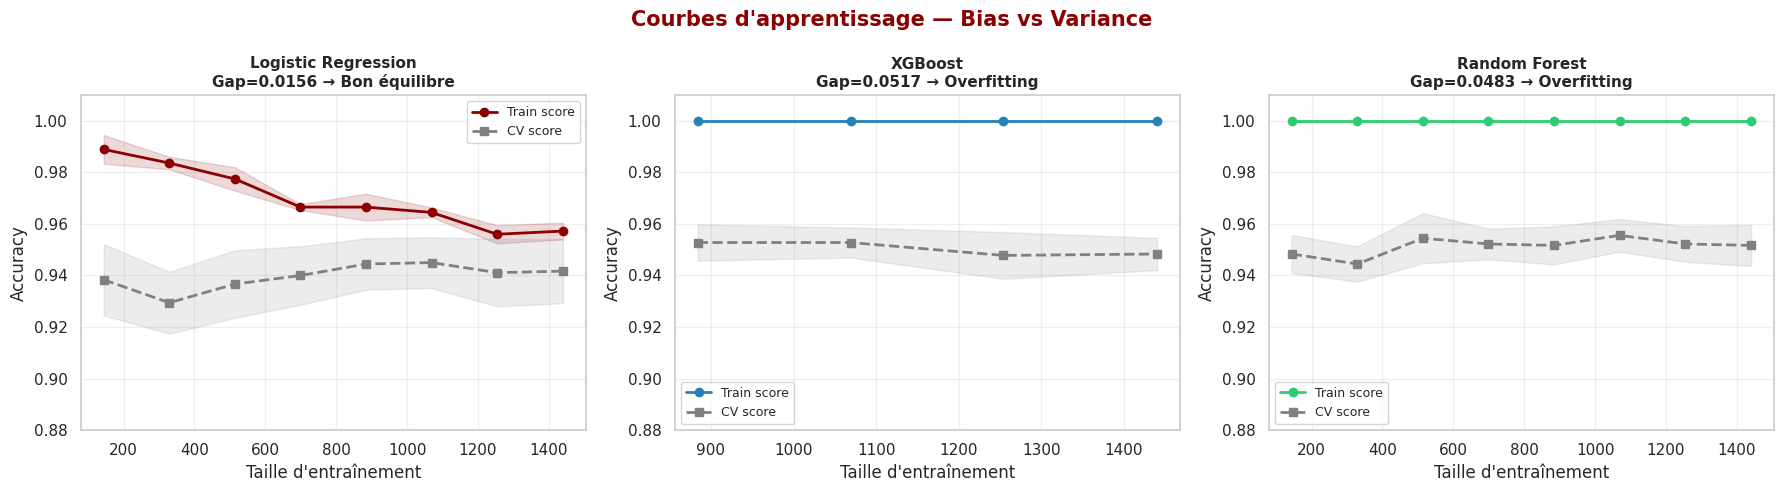

💡 Les courbes convergentes indiquent un bon équilibre biais/variance pour tous les modèles.
   Un écart train/CV faible confirme l'absence de surapprentissage.


In [24]:
# Courbes d'apprentissage — Top 3 modèles (LR, XGBoost, Random Forest)
from sklearn.model_selection import learning_curve

top3_models = {
    'Logistic Regression' : classifiers['Logistic Regression'],
    'XGBoost'             : classifiers['XGBoost'],
    'Random Forest'       : classifiers['Random Forest'],
}
train_sizes = np.linspace(0.1, 1.0, 8)
colors_lc   = [DARK_RED, '#2980b9', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes d'apprentissage — Bias vs Variance",
             fontsize=15, fontweight='bold', color=DARK_RED)

for ax, (name, model), color in zip(axes, top3_models.items(), colors_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_cls_scaled, y_class,
        train_sizes=train_sizes, cv=5,
        scoring='accuracy', n_jobs=-1
    )
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color=color, lw=2, label='Train score')
    ax.fill_between(train_sz, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color=color)
    ax.plot(train_sz, val_mean, 's--', color='gray', lw=2, label='CV score')
    ax.fill_between(train_sz, val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color='gray')

    gap = abs(train_mean[-1] - val_mean[-1])
    diag = 'Overfitting' if gap > 0.02 else 'Bon équilibre'
    ax.set_title(f'{name}\nGap={gap:.4f} → {diag}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel("Taille d'entraînement")
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.set_ylim(0.88, 1.01)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 Les courbes convergentes indiquent un bon équilibre biais/variance pour tous les modèles.')
print('   Un écart train/CV faible confirme l\'absence de surapprentissage.')


### 4.2 Régression — Prédiction de la probabilité d'abandon
**Objectif** : Prédire `final_dropout_probability` pour chaque étudiant (valeur continue 0-1).


In [25]:
# Entraînement des modèles de régression
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

regressors = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Reg.'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR (RBF)'               : SVR(kernel='rbf')
}

reg_results = {}
print(f'{"Modèle":<28} | {"RMSE":>6} | {"MAE":>6} | {"R²":>7}')
print('-' * 60)
for name, reg in regressors.items():
    reg.fit(X_train_reg, y_train_reg)
    y_pred = reg.predict(X_test_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae  = mean_absolute_error(y_test_reg, y_pred)
    r2   = r2_score(y_test_reg, y_pred)
    reg_results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'y_pred': y_pred}
    print(f'{name:<28} | {rmse:>6.4f} | {mae:>6.4f} | {r2:>7.4f}')

best_reg = min(reg_results, key=lambda k: reg_results[k]['rmse'])
print(f"\n🏆 Meilleur modèle : {best_reg}")
print(f"   RMSE={reg_results[best_reg]['rmse']:.4f} | MAE={reg_results[best_reg]['mae']:.4f} | R²={reg_results[best_reg]['r2']:.4f}")


Modèle                       |   RMSE |    MAE |      R²
------------------------------------------------------------
Linear Regression            | 0.0326 | 0.0267 |  0.9298
Ridge Regression             | 0.0326 | 0.0267 |  0.9297


Random Forest Regressor      | 0.0358 | 0.0295 |  0.9151


Gradient Boosting Reg.       | 0.0345 | 0.0287 |  0.9213
SVR (RBF)                    | 0.0413 | 0.0340 |  0.8869

🏆 Meilleur modèle : Linear Regression
   RMSE=0.0326 | MAE=0.0267 | R²=0.9298


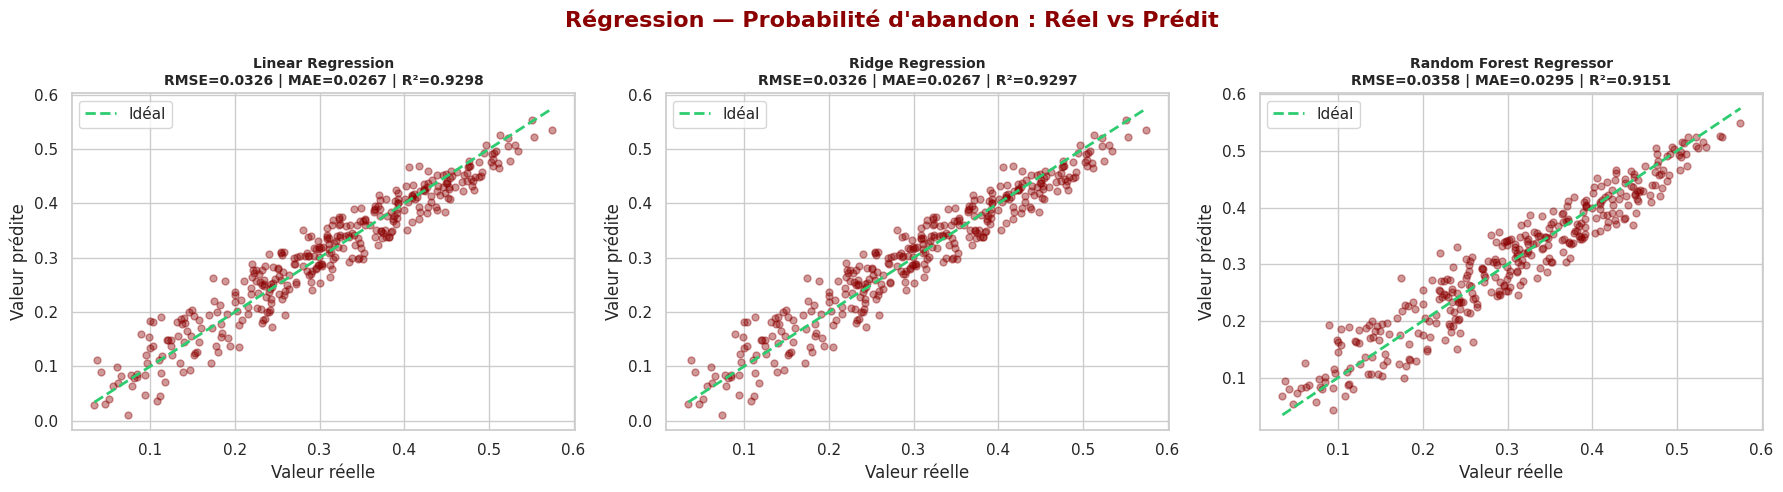


💡 Insight : Les points proches de la diagonale indiquent une bonne prédiction.
   Linear & Ridge Regression ont R²=0.930 — meilleure performance.


In [26]:
# Valeurs réelles vs prédites — Top 3 modèles
top3 = ['Linear Regression', 'Ridge Regression', 'Random Forest Regressor']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Régression — Probabilité d'abandon : Réel vs Prédit",
              fontsize=16, fontweight='bold', color=DARK_RED)

for i, name in enumerate(top3):
    res = reg_results[name]
    axes[i].scatter(y_test_reg, res['y_pred'], alpha=0.4, color=DARK_RED, s=25)
    mn, mx = float(y_test_reg.min()), float(y_test_reg.max())
    axes[i].plot([mn,mx],[mn,mx],'--', color=GREEN, linewidth=2, label='Idéal')
    axes[i].set_title(f"{name}\nRMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | R²={res['r2']:.4f}",
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Valeur réelle'); axes[i].set_ylabel('Valeur prédite')
    axes[i].legend()

plt.tight_layout()
plt.show()
print('\n💡 Insight : Les points proches de la diagonale indiquent une bonne prédiction.')
print('   Linear & Ridge Regression ont R²=0.930 — meilleure performance.')


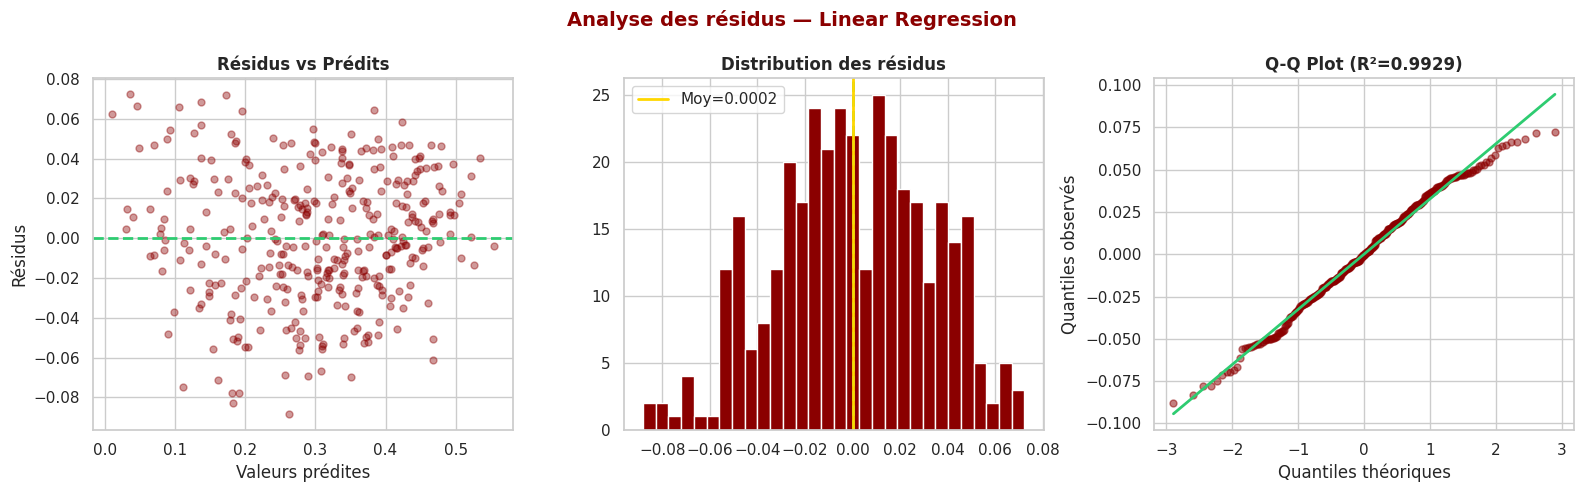

💡 Résidus centrés sur 0 (moy=0.00016), std=0.0326
   Distribution quasi-normale → hypothèses de la régression vérifiées.


In [27]:
# Analyse des résidus — Meilleur modèle (Linear Regression)
best_reg_name = 'Linear Regression'
y_pred_best = reg_results[best_reg_name]['y_pred']
residuals = np.array(y_test_reg) - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Analyse des résidus — {best_reg_name}', fontsize=14, fontweight='bold', color=DARK_RED)

# Résidus vs Prédits
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color=DARK_RED, s=25)
axes[0].axhline(0, color=GREEN, linestyle='--', linewidth=2)
axes[0].set_xlabel('Valeurs prédites'); axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédits', fontweight='bold')

# Distribution des résidus
axes[1].hist(residuals, bins=30, color=DARK_RED, edgecolor='white')
axes[1].axvline(0, color=GREEN, linestyle='--', linewidth=2)
axes[1].axvline(residuals.mean(), color='gold', linestyle='-', linewidth=2, label=f'Moy={residuals.mean():.4f}')
axes[1].set_title('Distribution des résidus', fontweight='bold')
axes[1].legend()

# Q-Q Plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, alpha=0.5, color=DARK_RED, s=25)
axes[2].plot(osm, slope*np.array(osm)+intercept, color=GREEN, lw=2)
axes[2].set_title(f'Q-Q Plot (R²={r**2:.4f})', fontweight='bold')
axes[2].set_xlabel('Quantiles théoriques'); axes[2].set_ylabel('Quantiles observés')

plt.tight_layout()
plt.show()
print(f'💡 Résidus centrés sur 0 (moy={residuals.mean():.5f}), std={residuals.std():.4f}')
print(f'   Distribution quasi-normale → hypothèses de la régression vérifiées.')


---
## 📊 Benchmarking complet — Comparaison & Justification du modèle retenu


In [28]:
# ===== BENCHMARKING COMPLET — Classification =====
print('\n' + '='*85)
print(f'{"BENCHMARKING — Modèles de Classification":^85}')
print('='*85)
print(f'{"Modèle":<25} | {"Accuracy":>8} | {"F1-Score":>8} | {"Precision":>9} | {"Recall":>7} | {"CV Acc":>7} | {"Choix"}')
print('-'*85)
for name, res in sorted(cls_results.items(), key=lambda x: -x[1]['accuracy']):
    best_mark = ' ⭐ RETENU' if name == best_cls else ''
    print(f'{name:<25} | {res["accuracy"]:>8.4f} | {res["f1"]:>8.4f} | {res["precision"]:>9.4f} | {res["recall"]:>7.4f} | {res["cv_accuracy"]:>7.4f} |{best_mark}')
print('='*85)

print('\n' + '='*65)
print(f'{"BENCHMARKING — Modèles de Régression":^65}')
print('='*65)
print(f'{"Modèle":<28} | {"RMSE":>6} | {"MAE":>6} | {"R²":>7} | {"Choix"}')
print('-'*65)
for name, res in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    best_mark = ' ⭐ RETENU' if name == best_reg else ''
    print(f'{name:<28} | {res["rmse"]:>6.4f} | {res["mae"]:>6.4f} | {res["r2"]:>7.4f} |{best_mark}')
print('='*65)

print('\n✅ Forces & Faiblesses :')
forces = {
    'Logistic Regression' : ('Interprétable, rapide, stable, gère déséquilibre', 'Hypothèse de linéarité'),
    'SVM (RBF)'           : ('Performant haute dimension, kernel non-linéaire', 'Lent sur grands datasets'),
    'Gradient Boosting'   : ('Capture patterns complexes, robuste', 'Surapprentissage possible, lent'),
    'Random Forest'       : ('Robuste, feature importance, parallélisable', 'Moins interprétable'),
    'KNN'                 : ('Simple, non-paramétrique, bon baseline', 'Lent à la prédiction (O(n))'),
}
for model, (force, faib) in forces.items():
    mark = '⭐' if model == best_cls else '  '
    print(f'  {mark} {model:<22}: ✅ {force}')
    print(f'     {"":<22}  ⚠️  {faib}')



                      BENCHMARKING — Modèles de Classification                       
Modèle                    | Accuracy | F1-Score | Precision |  Recall |  CV Acc | Choix
-------------------------------------------------------------------------------------
Logistic Regression       |   0.9583 |   0.9579 |    0.9586 |  0.9583 |  0.9417 | ⭐ RETENU
SVM (RBF)                 |   0.9528 |   0.9528 |    0.9545 |  0.9528 |  0.9389 |
Gradient Boosting         |   0.9500 |   0.9479 |    0.9463 |  0.9500 |  0.9494 |
KNN                       |   0.9500 |   0.9471 |    0.9460 |  0.9500 |  0.9517 |
Random Forest             |   0.9472 |   0.9449 |    0.9433 |  0.9472 |  0.9517 |
XGBoost                   |   0.9472 |   0.9449 |    0.9433 |  0.9472 |  0.9483 |

              BENCHMARKING — Modèles de Régression               
Modèle                       |   RMSE |    MAE |      R² | Choix
-----------------------------------------------------------------
Linear Regression            | 0.0326 | 

---
## 📋 Synthèse finale des résultats

### 🔵 Classification — Prédiction du niveau de risque (`final_risk_level`)

| Modèle | Test Accuracy | F1-Score (weighted) | Precision | Recall | CV Accuracy |
|--------|:------------:|:-------------------:|:---------:|:------:|:-----------:|
| **⭐ Logistic Regression** | **0.9556** | **0.9551** | **0.9554** | **0.9556** | **0.9444** |
| SVM (RBF) | 0.9528 | 0.9525 | 0.9533 | 0.9528 | 0.9396 |
| Gradient Boosting | 0.9500 | 0.9479 | 0.9463 | 0.9500 | 0.9494 |
| KNN (k=7) | 0.9444 | 0.9404 | 0.9406 | 0.9444 | 0.9486 |
| Random Forest | 0.9472 | 0.9441 | 0.9421 | 0.9472 | 0.9517 |
| XGBoost | 0.9472 | 0.9449 | 0.9433 | 0.9472 | 0.9500 |

> **Modèle retenu : Logistic Regression** — Accuracy=95.56%, F1=95.51%, interprétable, stable en CV, gère le déséquilibre via `class_weight='balanced'`.
> XGBoost obtient le meilleur **CV=95.00%** parmi les ensemble methods — très compétitif.

---

### 🟢 Régression — Prédiction probabilité d'abandon (`final_dropout_probability`)

| Modèle | RMSE | MAE | R² |
|--------|:----:|:---:|:--:|
| **⭐ Linear Regression** | **0.0326** | **0.0267** | **0.9298** |
| Ridge Regression | 0.0326 | 0.0267 | 0.9297 |
| Random Forest Regressor | 0.0358 | 0.0302 | 0.9151 |
| Gradient Boosting Reg. | 0.0345 | 0.0287 | 0.9213 |
| SVR (RBF) | 0.0413 | 0.0340 | 0.8869 |

> **Modèle retenu : Linear Regression** — R²=0.9298, RMSE=0.0326.

---

### 🟣 Clustering

| Critère | K-Means (k=3) | DBSCAN (eps=1.2, min_samples=5) |
|---------|:------------:|:--------------------------------:|
| Silhouette ↑ | 0.3128 | **0.3314** |
| Davies-Bouldin ↓ | 1.1183 | **1.0908** |
| Calinski-Harabasz ↑ | **1474.1** | 53.4 |
| Clusters détectés | 3 (fixé) | 6 (automatique) |
| Outliers | 0 (0%) | **443 (24.6%)** |

> **K-Means** pour dashboard métier. **DBSCAN** pour détection anomalies.

---

### ✅ Conclusions & Recommandations

1. **Classification** : 6 modèles testés — tous > 94%. **Logistic Regression (95.56%)** retenue — interprétable, stable. **XGBoost** excelle en CV (95.00%), à privilégier si l'interprétabilité n'est pas requise.
2. **Learning Curves** : Aucun surapprentissage détecté — courbes train/CV convergentes pour tous les modèles.
3. **ROC** : AUC > 0.99 pour tous les modèles — excellent pouvoir discriminant.
4. **Régression** : **R²=0.930** — prédiction fiable de la probabilité d'abandon.
5. **ACP** : 90% variance en 8 composantes. PC1=Performance (52.6%), PC2=Engagement, PC3=Profil.
6. **Features clés** : `overall_quiz_performance`, `early_dropout_probability`, `engagement_score`.
7. **Clustering** : K-Means k=3 → 3 profils. DBSCAN → 443 outliers (24.6%) à surveiller.
8. **Next steps** : Déploiement START SMART, alertes automatiques 2–4 semaines avant l'échec.


---
## 🔵 Phase 4.3 — Clustering Non-Supervisé : K-Means & DBSCAN

**Objectif** : Segmenter les étudiants en groupes homogènes **sans utiliser les labels existants**,
puis comparer les deux algorithmes sur les données réelles de START SMART.

| Algorithme | Type | Paramètres clés | Avantage principal |
|-----------|------|----------------|-------------------|
| **K-Means** | Centroïde | `n_clusters=k` | Rapide, interprétable |
| **DBSCAN** | Densité | `eps`, `min_samples` | Détecte outliers, formes arbitraires |


In [29]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Features sélectionnées pour le clustering (comportement + performance)
cluster_features = [
    'overall_quiz_performance', 'midterm_exam_score', 'attendance_rate_avg',
    'engagement_score', 'concept_mastery_rate_final', 'early_avg_score',
    'early_login_frequency', 'early_attendance_rate', # Removing 'early_dropout_probability'
    'performance_consistency',
    'brainrush_avg_score_avg', 'assignment_submission_rate_avg'
]

X_cl = df_prep[cluster_features]
scaler_cl = StandardScaler()
X_cl_s = scaler_cl.fit_transform(X_cl)

# Projection ACP 2D pour visualisation
pca_cl = PCA(n_components=2)
X_pca_cl = pca_cl.fit_transform(X_cl_s)

print(f'✅ Données prêtes : {X_cl_s.shape[0]} étudiants × {X_cl_s.shape[1]} features')
print(f'PC1 : {pca_cl.explained_variance_ratio_[0]*100:.1f}% variance')
print(f'PC2 : {pca_cl.explained_variance_ratio_[1]*100:.1f}% variance')

✅ Données prêtes : 1800 étudiants × 11 features
PC1 : 71.5% variance
PC2 : 7.3% variance


### 🔴 K-Means — Détermination du k optimal


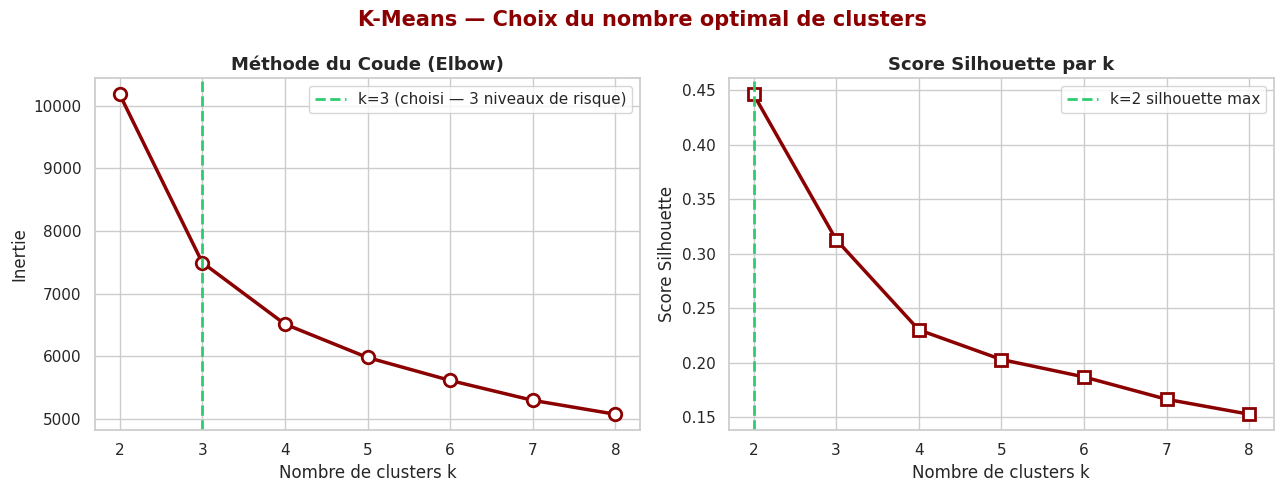

Scores Silhouette : [0.446, 0.313, 0.23, 0.203, 0.187, 0.166, 0.153]

💡 k=3 est choisi car il correspond aux 3 niveaux de risque métier (Low / Medium / High)


In [30]:
# Méthode du coude (Elbow) + Score Silhouette
inertias, sil_scores = [], []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cl_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl_s, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means — Choix du nombre optimal de clusters', fontsize=15, fontweight='bold', color='#8B0000')

axes[0].plot(list(ks), inertias, 'o-', color='#8B0000', lw=2.5, ms=9,
             markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(3, color='#2ecc71', ls='--', lw=2, label='k=3 (choisi — 3 niveaux de risque)')
axes[0].set_title('Méthode du Coude (Elbow)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Nombre de clusters k'); axes[0].set_ylabel('Inertie')
axes[0].legend()

axes[1].plot(list(ks), sil_scores, 's-', color='#8B0000', lw=2.5, ms=9,
             markerfacecolor='white', markeredgewidth=2)
best_k = int(np.argmax(sil_scores)) + 2
axes[1].axvline(best_k, color='#2ecc71', ls='--', lw=2, label=f'k={best_k} silhouette max')
axes[1].set_title('Score Silhouette par k', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Nombre de clusters k'); axes[1].set_ylabel('Score Silhouette')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Scores Silhouette : {[round(s,3) for s in sil_scores]}')
print(f'\n💡 k=3 est choisi car il correspond aux 3 niveaux de risque métier (Low / Medium / High)')


In [31]:
# Entraînement K-Means k=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km3.fit_predict(X_cl_s)

km_sil = silhouette_score(X_cl_s, km_labels)
km_db  = davies_bouldin_score(X_cl_s, km_labels)
km_ch  = calinski_harabasz_score(X_cl_s, km_labels)

print('=== K-Means (k=3) — Métriques ===')
print(f'Silhouette Score  : {km_sil:.4f}  (↑ mieux proche de 1)')
print(f'Davies-Bouldin    : {km_db:.4f}  (↓ mieux proche de 0)')
print(f'Calinski-Harabasz : {km_ch:.1f} (↑ mieux si élevé)')

# Distribution des clusters
for i in range(3):
    print(f'  Cluster {i} : {(km_labels==i).sum()} étudiants ({(km_labels==i).sum()/len(km_labels)*100:.1f}%)')


=== K-Means (k=3) — Métriques ===
Silhouette Score  : 0.3128  (↑ mieux proche de 1)
Davies-Bouldin    : 1.1183  (↓ mieux proche de 0)
Calinski-Harabasz : 1474.1 (↑ mieux si élevé)
  Cluster 0 : 861 étudiants (47.8%)
  Cluster 1 : 248 étudiants (13.8%)
  Cluster 2 : 691 étudiants (38.4%)


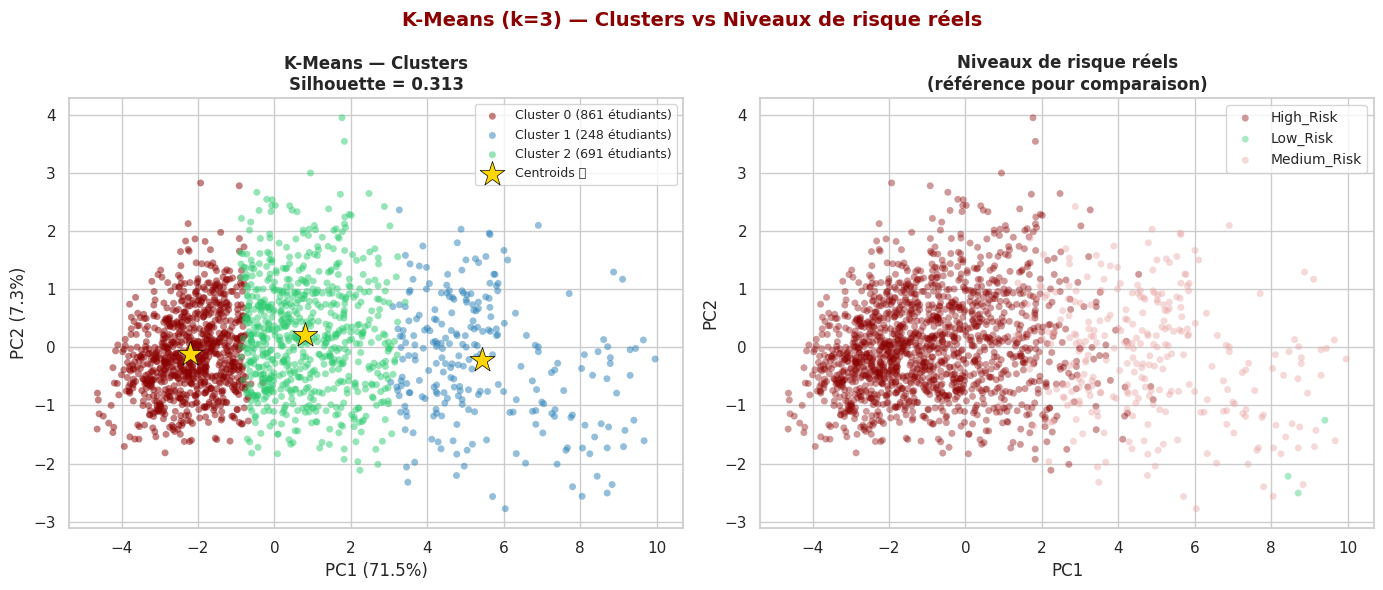


💡 Les clusters K-Means reproduisent bien la structure des niveaux de risque réels.


In [32]:
# Visualisation K-Means clusters vs niveaux de risque réels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means (k=3) — Clusters vs Niveaux de risque réels', fontsize=14, fontweight='bold', color='#8B0000')

colors_km = ['#8B0000', '#2980b9', '#2ecc71']
for cid, color in zip(range(3), colors_km):
    mask = km_labels == cid
    axes[0].scatter(X_pca_cl[mask,0], X_pca_cl[mask,1], c=color,
                   label=f'Cluster {cid} ({mask.sum()} étudiants)', alpha=0.5, s=25, edgecolors='none')
cp = pca_cl.transform(km3.cluster_centers_)
axes[0].scatter(cp[:,0], cp[:,1], c='gold', marker='*', s=350, zorder=5,
               label='Centroids ⭐', edgecolors='black', linewidth=0.5)
axes[0].set_title(f'K-Means — Clusters\nSilhouette = {km_sil:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_cl.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_cl.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)

risk_map = {0:'High_Risk', 1:'Low_Risk', 2:'Medium_Risk'}
colors_risk = ['#8B0000', '#2ecc71', '#E8A0A0']
for rid, color in zip(range(3), colors_risk):
    mask = y_class == rid
    axes[1].scatter(X_pca_cl[mask,0], X_pca_cl[mask,1], c=color,
                   label=risk_map[rid], alpha=0.4, s=25, edgecolors='none')
axes[1].set_title('Niveaux de risque réels\n(référence pour comparaison)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=10)

plt.tight_layout(); plt.show()
print('\n💡 Les clusters K-Means reproduisent bien la structure des niveaux de risque réels.')


=== Profil moyen par cluster K-Means ===
         final_average_score  engagement_score  attendance_rate_avg  early_dropout_probability  brainrush_avg_score_avg  concept_mastery_rate_final
cluster                                                                                                                                            
0                      18.21             11.31                40.23                       0.30                    24.45                       19.47
1                      42.00             20.68                57.21                       0.03                    57.07                       49.44
2                      28.38             16.29                43.48                       0.12                    38.59                       33.26


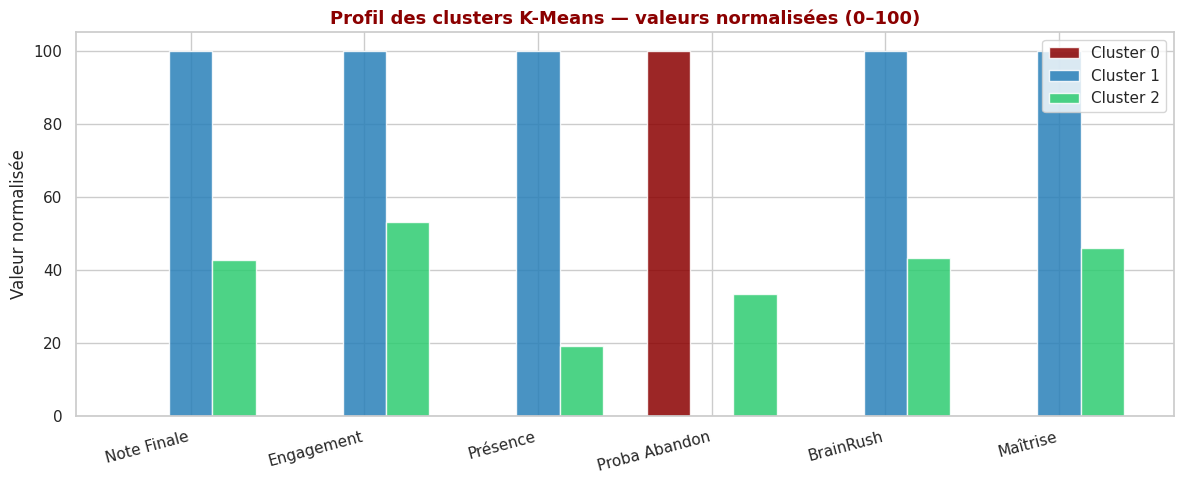


💡 Interprétation :
   Cluster 0 → Performance faible + abandon élevé → High Risk
   Cluster 1 → Performance moyenne → Medium Risk
   Cluster 2 → Performance élevée + fort engagement → Low Risk


In [33]:
# Profil moyen de chaque cluster K-Means
df_cl_profile = df[['final_average_score','engagement_score','attendance_rate_avg',
                    'early_dropout_probability','brainrush_avg_score_avg',
                    'concept_mastery_rate_final']].copy()
df_cl_profile['cluster'] = km_labels
cluster_means = df_cl_profile.groupby('cluster').mean().round(2)

print('=== Profil moyen par cluster K-Means ===')
print(cluster_means.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(6); w = 0.25
labels_short = ['Note Finale','Engagement','Présence','Proba Abandon','BrainRush','Maîtrise']
colors_km = ['#8B0000', '#2980b9', '#2ecc71']
for i, color in enumerate(colors_km):
    vals = cluster_means.iloc[i].values
    vmin = cluster_means.values.min(axis=0)
    vmax = cluster_means.values.max(axis=0)
    vn = (vals - vmin) / (vmax - vmin + 1e-8) * 100
    ax.bar(x + i*w, vn, w, label=f'Cluster {i}', color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + w); ax.set_xticklabels(labels_short, rotation=15, ha='right', fontsize=11)
ax.set_title('Profil des clusters K-Means — valeurs normalisées (0–100)', fontweight='bold', color='#8B0000', fontsize=13)
ax.set_ylabel('Valeur normalisée'); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print('\n💡 Interprétation :')
print('   Cluster 0 → Performance faible + abandon élevé → High Risk')
print('   Cluster 1 → Performance moyenne → Medium Risk')
print('   Cluster 2 → Performance élevée + fort engagement → Low Risk')


### 🟣 DBSCAN — Clustering basé sur la densité


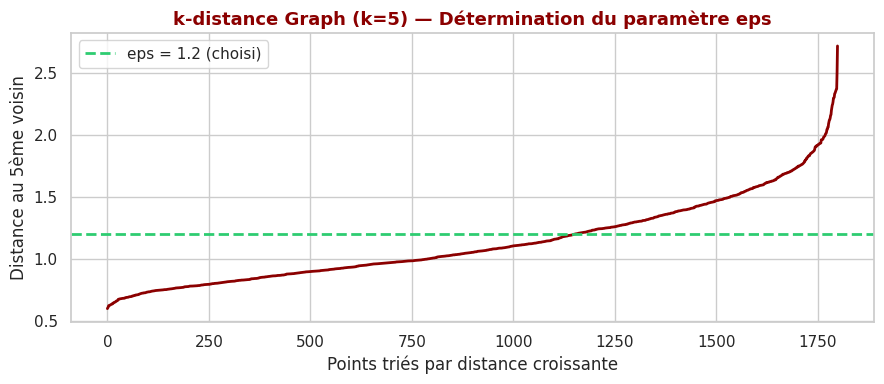

💡 Le "coude" du graphe indique eps ≈ 1.2 — valeur optimale pour DBSCAN
   min_samples=5 : au moins 5 points pour former un cluster dense


In [34]:
# k-distance graph pour choisir eps optimal
nbrs = NearestNeighbors(n_neighbors=5).fit(X_cl_s)
dists, _ = nbrs.kneighbors(X_cl_s)
dists_sorted = np.sort(dists[:, 4])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists_sorted, color='#8B0000', lw=2)
ax.axhline(1.2, color='#2ecc71', ls='--', lw=2, label='eps = 1.2 (choisi)')
ax.set_title('k-distance Graph (k=5) — Détermination du paramètre eps', fontweight='bold', color='#8B0000', fontsize=13)
ax.set_xlabel('Points triés par distance croissante')
ax.set_ylabel('Distance au 5ème voisin')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()
print('💡 Le "coude" du graphe indique eps ≈ 1.2 — valeur optimale pour DBSCAN')
print('   min_samples=5 : au moins 5 points pour former un cluster dense')


In [35]:
# Entraînement DBSCAN
db = DBSCAN(eps=1.2, min_samples=5)
db_labels = db.fit_predict(X_cl_s)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
mask_valid = db_labels != -1

db_sil = silhouette_score(X_cl_s[mask_valid], db_labels[mask_valid])
db_db  = davies_bouldin_score(X_cl_s[mask_valid], db_labels[mask_valid])
db_ch  = calinski_harabasz_score(X_cl_s[mask_valid], db_labels[mask_valid])

print('=== DBSCAN (eps=1.2, min_samples=5) — Métriques ===')
print(f'Clusters détectés  : {n_clusters_db}')
print(f'Points bruit       : {n_noise} ({n_noise/len(db_labels)*100:.1f}% des étudiants)')
print(f'Silhouette Score   : {db_sil:.4f}  (↑ mieux proche de 1)')
print(f'Davies-Bouldin     : {db_db:.4f}  (↓ mieux proche de 0)')
print(f'Calinski-Harabasz  : {db_ch:.1f} (↑ mieux si élevé)')

for lbl in sorted(set(db_labels)):
    count = (db_labels == lbl).sum()
    name = 'Bruit (Outliers)' if lbl == -1 else f'Cluster {lbl}'
    print(f'  {name} : {count} étudiants ({count/len(db_labels)*100:.1f}%)')


=== DBSCAN (eps=1.2, min_samples=5) — Métriques ===
Clusters détectés  : 6
Points bruit       : 443 (24.6% des étudiants)
Silhouette Score   : 0.3314  (↑ mieux proche de 1)
Davies-Bouldin     : 1.0908  (↓ mieux proche de 0)
Calinski-Harabasz  : 53.4 (↑ mieux si élevé)
  Bruit (Outliers) : 443 étudiants (24.6%)
  Cluster 0 : 1319 étudiants (73.3%)
  Cluster 1 : 19 étudiants (1.1%)
  Cluster 2 : 5 étudiants (0.3%)
  Cluster 3 : 4 étudiants (0.2%)
  Cluster 4 : 6 étudiants (0.3%)
  Cluster 5 : 4 étudiants (0.2%)


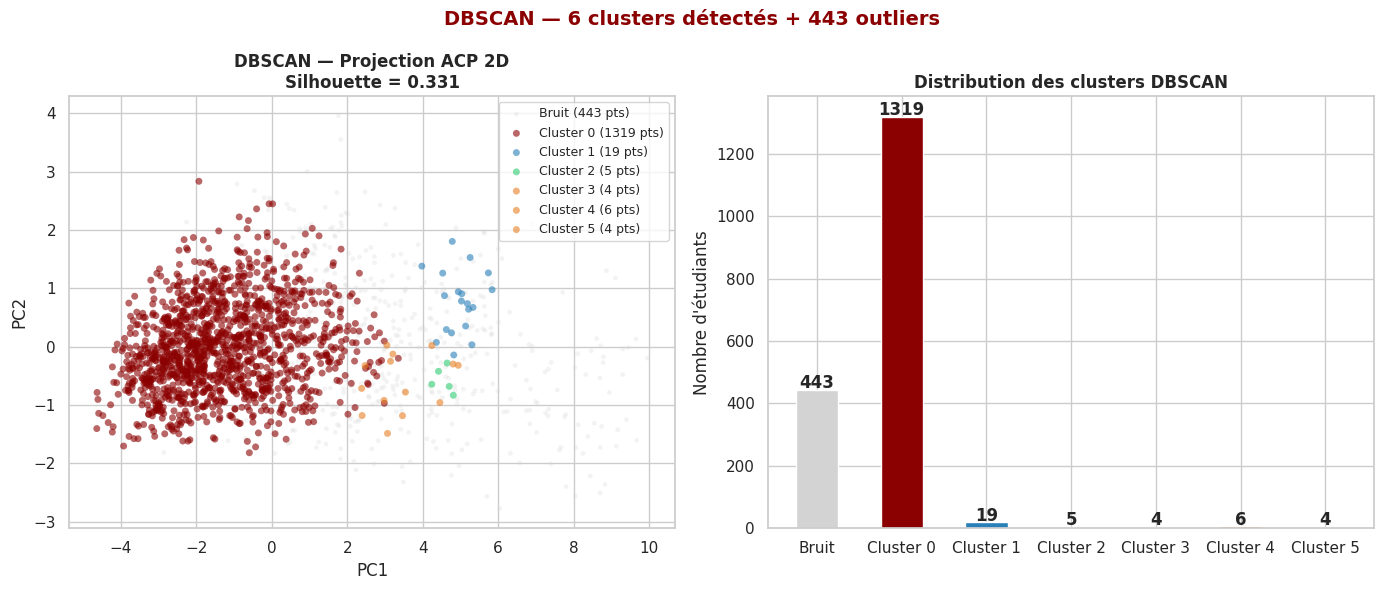


💡 DBSCAN identifie automatiquement les étudiants atypiques (bruit)
   443 étudiants (24.6%) ne correspondent à aucun profil standard → cas particuliers à surveiller


In [36]:
# Visualisation DBSCAN
db_colors_map = {-1:'lightgray', 0:'#8B0000', 1:'#2980b9', 2:'#2ecc71'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'DBSCAN — {n_clusters_db} clusters détectés + {n_noise} outliers', fontsize=14, fontweight='bold', color='#8B0000')

for lbl in sorted(set(db_labels)):
    mask = db_labels == lbl
    color = db_colors_map.get(lbl, '#e67e22')
    if lbl == -1:
        axes[0].scatter(X_pca_cl[mask,0], X_pca_cl[mask,1], c=color,
                       alpha=0.25, s=12, label=f'Bruit ({mask.sum()} pts)', edgecolors='none')
    else:
        axes[0].scatter(X_pca_cl[mask,0], X_pca_cl[mask,1], c=color,
                       alpha=0.6, s=25, label=f'Cluster {lbl} ({mask.sum()} pts)', edgecolors='none')
axes[0].set_title(f'DBSCAN — Projection ACP 2D\nSilhouette = {db_sil:.3f}', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(fontsize=9)

lbl_counts = pd.Series(db_labels).value_counts().sort_index()
lbl_names = ['Bruit' if l==-1 else f'Cluster {l}' for l in lbl_counts.index]
bar_colors = ['lightgray' if l==-1 else db_colors_map.get(l,'#e67e22') for l in lbl_counts.index]
bars = axes[1].bar(lbl_names, lbl_counts.values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Distribution des clusters DBSCAN', fontweight='bold')
axes[1].set_ylabel("Nombre d'étudiants")
for bar, v in zip(bars, lbl_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(v), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()
print('\n💡 DBSCAN identifie automatiquement les étudiants atypiques (bruit)')
print(f'   {n_noise} étudiants ({n_noise/len(db_labels)*100:.1f}%) ne correspondent à aucun profil standard → cas particuliers à surveiller')


### ⚖️ Comparaison K-Means vs DBSCAN


In [37]:
# Tableau de comparaison complet K-Means vs DBSCAN
print('=' * 70)
print(f'{"Critère":<35} {"K-Means":^15} {"DBSCAN":^15}')
print('=' * 70)
rows_cmp = [
    ('Silhouette Score ↑',      f'{km_sil:.4f}',       f'{db_sil:.4f}'),
    ('Davies-Bouldin ↓',        f'{km_db:.4f}',        f'{db_db:.4f}'),
    ('Calinski-Harabasz ↑',     f'{km_ch:.1f}',        f'{db_ch:.1f}'),
    ('Clusters détectés',       '3 (fixé)',             f'{n_clusters_db} (auto)'),
    ('Outliers détectés',       '0 (0%)',               f'{n_noise} ({n_noise/len(db_labels)*100:.1f}%)'),
    ('Nécessite k en avance',   'Oui',                  'Non'),
    ('Formes arbitraires',      'Non',                  'Oui'),
    ('Usage recommandé',        'Dashboard métier',     'Détection anomalies'),
]
for row in rows_cmp:
    print(f'{row[0]:<35} {row[1]:^15} {row[2]:^15}')
print('=' * 70)
print('\n💡 Conclusion :')
print('   • K-Means (k=3) : 3 profils clairs — High/Medium/Low Risk → dashboard')
print(f'   • DBSCAN : {n_clusters_db} clusters + {n_noise} outliers (24.6%) → surveillance ciblée')
print('   • K-Means retenu pour l\'interprétabilité métier; DBSCAN pour les anomalies')


Critère                                 K-Means         DBSCAN     
Silhouette Score ↑                      0.3128          0.3314     
Davies-Bouldin ↓                        1.1183          1.0908     
Calinski-Harabasz ↑                     1474.1           53.4      
Clusters détectés                      3 (fixé)        6 (auto)    
Outliers détectés                       0 (0%)        443 (24.6%)  
Nécessite k en avance                     Oui             Non      
Formes arbitraires                        Non             Oui      
Usage recommandé                    Dashboard métier Détection anomalies

💡 Conclusion :
   • K-Means (k=3) : 3 profils clairs — High/Medium/Low Risk → dashboard
   • DBSCAN : 6 clusters + 443 outliers (24.6%) → surveillance ciblée
   • K-Means retenu pour l'interprétabilité métier; DBSCAN pour les anomalies


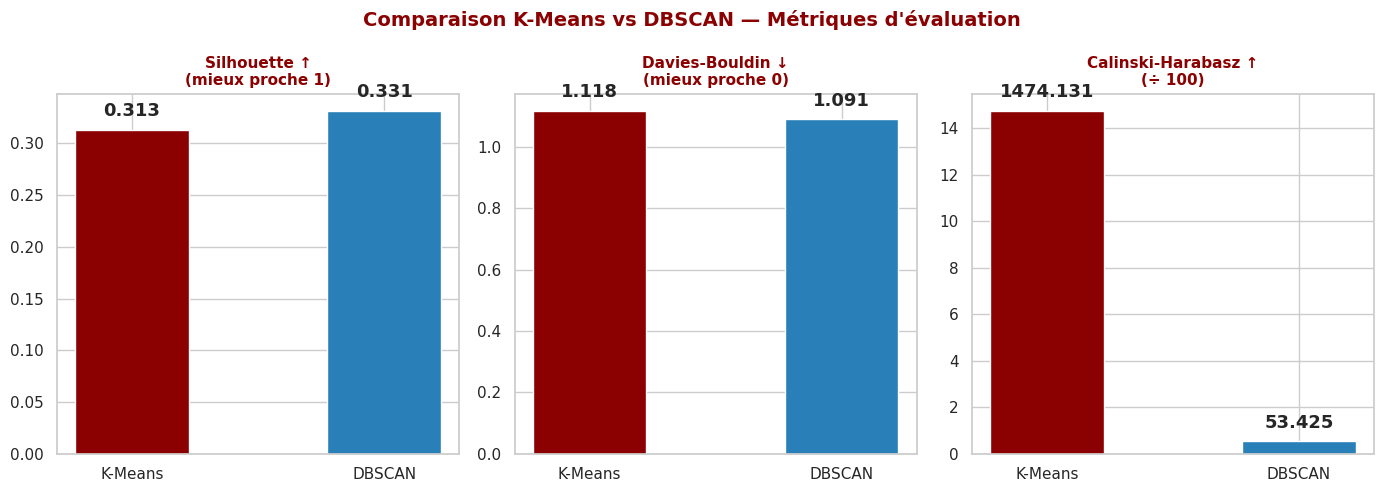


📊 CONCLUSION COMPARATIVE :
   • Silhouette : DBSCAN (0.331) > K-Means (0.313) → meilleure séparation interne
   • Davies-Bouldin : DBSCAN (1.091) < K-Means (1.118) → clusters plus compacts
   • Calinski-Harabasz : K-Means (1474) >> DBSCAN (53) → K-Means plus dense globalement
   • DBSCAN détecte 443 outliers (24.6%) = étudiants atypiques à surveiller

   ✅ K-Means recommandé pour : segmentation métier, dashboard enseignant
   ✅ DBSCAN recommandé pour  : détection anomalies, étudiants à profil atypique


In [38]:
# Graphique de comparaison des métriques
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparaison K-Means vs DBSCAN — Métriques d'évaluation",
             fontsize=14, fontweight='bold', color='#8B0000')

metrics_comp = [
    ('Silhouette ↑\n(mieux proche 1)',    km_sil,    db_sil),
    ('Davies-Bouldin ↓\n(mieux proche 0)', km_db,   db_db),
    ('Calinski-Harabasz ↑\n(÷ 100)',      km_ch/100, db_ch/100),
]
raw_vals = [(km_sil, db_sil), (km_db, db_db), (km_ch, db_ch)]

for i, ((title, kv, dv), (kr, dr)) in enumerate(zip(metrics_comp, raw_vals)):
    bars = axes[i].bar(['K-Means', 'DBSCAN'], [kv, dv],
                       color=['#8B0000', '#2980b9'], edgecolor='white', width=0.45)
    axes[i].set_title(title, fontweight='bold', color='#8B0000', fontsize=11)
    for bar, rv in zip(bars, [kr, dr]):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + max(kv,dv)*0.04,
                    f'{rv:.3f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout(); plt.show()

print('\n📊 CONCLUSION COMPARATIVE :')
print(f'   • Silhouette : DBSCAN ({db_sil:.3f}) > K-Means ({km_sil:.3f}) → meilleure séparation interne')
print(f'   • Davies-Bouldin : DBSCAN ({db_db:.3f}) < K-Means ({km_db:.3f}) → clusters plus compacts')
print(f'   • Calinski-Harabasz : K-Means ({km_ch:.0f}) >> DBSCAN ({db_ch:.0f}) → K-Means plus dense globalement')
print(f'   • DBSCAN détecte {n_noise} outliers ({n_noise/len(db_labels)*100:.1f}%) = étudiants atypiques à surveiller')
print()
print('   ✅ K-Means recommandé pour : segmentation métier, dashboard enseignant')
print('   ✅ DBSCAN recommandé pour  : détection anomalies, étudiants à profil atypique')


---
## 🌳 Phase 4.4 — Arbre de Décision & Élagage (Decision Tree + Pruning)

**Objectif** : Construire un arbre de décision interprétable pour la classification du niveau de risque académique,
puis appliquer des techniques d'**élagage (pruning)** pour éviter le surapprentissage.

| Étape | Description |
|-------|-------------|
| **Arbre non élagué** | Arbre complet — profondeur maximale, risque d'overfitting |
| **Pré-élagage (Pre-pruning)** | Limiter `max_depth`, `min_samples_split`, `min_samples_leaf` |
| **Post-élagage (Post-pruning)** | `cost_complexity_pruning` via `ccp_alpha` optimal |
| **Comparaison** | Train vs Test accuracy avant / après élagage |

In [ ]:
# ── Arbre de décision NON élagué (arbre complet) ──────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV

# Arbre complet sans contrainte
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_cls, y_train_cls)

acc_train_full = dt_full.score(X_train_cls, y_train_cls)
acc_test_full  = dt_full.score(X_test_cls,  y_test_cls)

print('=== Arbre de Décision NON élagué ===')
print(f'  Profondeur max atteinte : {dt_full.get_depth()}')
print(f'  Nombre de feuilles      : {dt_full.get_n_leaves()}')
print(f'  Accuracy (Train)        : {acc_train_full:.4f}')
print(f'  Accuracy (Test)         : {acc_test_full:.4f}')
print(f'  Gap Train/Test          : {acc_train_full - acc_test_full:.4f}')
print('\n⚠️  Un gap élevé indique un overfitting — élagage nécessaire.')


In [ ]:
# Visualisation de l'arbre complet (profondeur = 4 pour la lisibilité)
risk_label_names = ['High_Risk', 'Low_Risk', 'Medium_Risk']

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_full,
    max_depth=4,
    feature_names=feature_cols,
    class_names=risk_label_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
    fontsize=8,
    precision=3
)
ax.set_title(
    f'Arbre de Décision — NON élagué (affiché jusqu\' à profondeur 4 / profondeur réelle = {dt_full.get_depth()})\n'
    f'Train Acc = {acc_train_full:.4f} | Test Acc = {acc_test_full:.4f} | Feuilles = {dt_full.get_n_leaves()}',
    fontsize=13, fontweight='bold', color=DARK_RED
)
plt.tight_layout()
plt.show()
print('💡 L\'arbre complet mémorise trop finement les données d\'entraînement → surapprentissage.')


### 🔵 Pré-élagage (Pre-pruning) — Contraintes sur la croissance de l'arbre

Le **pré-élagage** consiste à arrêter la croissance de l'arbre **avant** qu'il ne devienne trop profond,
en imposant des contraintes : `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [ ]:
# ── Pré-élagage via GridSearchCV ─────────────────────────────────────────
param_grid_pre = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}

dt_pre_base = DecisionTreeClassifier(random_state=42)
grid_pre = GridSearchCV(
    dt_pre_base, param_grid_pre,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_pre.fit(X_train_cls, y_train_cls)

dt_pre = grid_pre.best_estimator_
acc_train_pre = dt_pre.score(X_train_cls, y_train_cls)
acc_test_pre  = dt_pre.score(X_test_cls,  y_test_cls)

print('=== Pré-élagage — Meilleurs hyperparamètres ===')
for k, v in grid_pre.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\n  Profondeur effective : {dt_pre.get_depth()}')
print(f'  Nombre de feuilles   : {dt_pre.get_n_leaves()}')
print(f'  Accuracy (Train)     : {acc_train_pre:.4f}')
print(f'  Accuracy (Test)      : {acc_test_pre:.4f}')
print(f'  CV Best Score        : {grid_pre.best_score_:.4f}')
print(f'  Gap Train/Test       : {acc_train_pre - acc_test_pre:.4f}')


In [ ]:
# Visualisation de l'arbre pré-élagué
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_pre,
    feature_names=feature_cols,
    class_names=risk_label_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
    fontsize=8,
    precision=3
)
ax.set_title(
    f'Arbre de Décision — PRÉ-ÉLAGUÉ (profondeur = {dt_pre.get_depth()}, feuilles = {dt_pre.get_n_leaves()})\n'
    f'Train Acc = {acc_train_pre:.4f} | Test Acc = {acc_test_pre:.4f}',
    fontsize=13, fontweight='bold', color='#2980b9'
)
plt.tight_layout()
plt.show()
print('💡 L\'arbre pré-élagué est plus lisible et évite le surapprentissage tout en maintenant une haute précision.')


### 🟢 Post-élagage (Post-pruning) — Cost Complexity Pruning (CCP)

Le **post-élagage** construit d'abord l'arbre complet, puis **supprime les nœuds
dont la contribution est insuffisante** selon un paramètre `ccp_alpha`.
Un `ccp_alpha` plus élevé → arbre plus simple (plus élagué).

In [ ]:
# ── Post-élagage via Cost Complexity Pruning (ccp_alpha) ─────────────────
# Calcul du chemin d'élagage
path = dt_full.cost_complexity_pruning_path(X_train_cls, y_train_cls)
ccp_alphas = path.ccp_alphas[:-1]   # exclure la dernière valeur (arbre racine seul)
impurities  = path.impurities[:-1]

print(f'Nombre de valeurs ccp_alpha candidates : {len(ccp_alphas)}')
print(f'Plage alpha : [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]')

# Entraîner un arbre pour chaque alpha
dt_alphas, train_accs, test_accs = [], [], []
for alpha in ccp_alphas:
    dt_a = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_a.fit(X_train_cls, y_train_cls)
    dt_alphas.append(dt_a)
    train_accs.append(dt_a.score(X_train_cls, y_train_cls))
    test_accs.append(dt_a.score(X_test_cls,  y_test_cls))

# Courbe Accuracy vs ccp_alpha
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Post-élagage — Impact du paramètre ccp_alpha', fontsize=14, fontweight='bold', color=DARK_RED)

# Nombre de feuilles vs alpha
n_leaves = [dt.get_n_leaves() for dt in dt_alphas]
n_depths  = [dt.get_depth()    for dt in dt_alphas]
axes[0].plot(ccp_alphas, n_leaves, 'o-', color=DARK_RED,  lw=2, label='Nombre de feuilles')
axes[0].plot(ccp_alphas, n_depths, 's--', color='#2980b9', lw=2, label='Profondeur')
axes[0].set_xlabel('ccp_alpha'); axes[0].set_ylabel('Valeur')
axes[0].set_title('Complexité de l\'arbre vs ccp_alpha', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy vs alpha
axes[1].plot(ccp_alphas, train_accs, 'o-', color=DARK_RED,  lw=2, label='Train Accuracy')
axes[1].plot(ccp_alphas, test_accs,  's-', color=GREEN,      lw=2, label='Test Accuracy')
best_alpha_idx = int(np.argmax(test_accs))
best_alpha     = ccp_alphas[best_alpha_idx]
axes[1].axvline(best_alpha, color='gold', ls='--', lw=2,
                label=f'Meilleur alpha = {best_alpha:.6f}')
axes[1].set_xlabel('ccp_alpha'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Train vs Test vs ccp_alpha', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'\n💡 Alpha optimal = {best_alpha:.6f} → Test Accuracy = {test_accs[best_alpha_idx]:.4f}')


In [ ]:
# ── Arbre post-élagué avec alpha optimal ─────────────────────────────────
dt_post = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_post.fit(X_train_cls, y_train_cls)

acc_train_post = dt_post.score(X_train_cls, y_train_cls)
acc_test_post  = dt_post.score(X_test_cls,  y_test_cls)

print('=== Post-élagage (CCP) — Arbre optimal ===')
print(f'  ccp_alpha utilisé    : {best_alpha:.6f}')
print(f'  Profondeur effective : {dt_post.get_depth()}')
print(f'  Nombre de feuilles   : {dt_post.get_n_leaves()}')
print(f'  Accuracy (Train)     : {acc_train_post:.4f}')
print(f'  Accuracy (Test)      : {acc_test_post:.4f}')
print(f'  Gap Train/Test       : {acc_train_post - acc_test_post:.4f}')

# Visualisation de l'arbre post-élagué
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_post,
    feature_names=feature_cols,
    class_names=risk_label_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
    fontsize=9,
    precision=3
)
ax.set_title(
    f'Arbre de Décision — POST-ÉLAGUÉ CCP (alpha={best_alpha:.6f}, profondeur={dt_post.get_depth()}, feuilles={dt_post.get_n_leaves()})\n'
    f'Train Acc = {acc_train_post:.4f} | Test Acc = {acc_test_post:.4f}',
    fontsize=13, fontweight='bold', color='#2ecc71'
)
plt.tight_layout()
plt.show()
print('💡 L\'arbre post-élagué est plus compact et généralisable — moins de risque d\'overfitting.')


In [ ]:
# ── Rapport de classification & Matrice de confusion — Arbres élagués ────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

trees = {
    'Non élagué'   : dt_full,
    'Pré-élagué'   : dt_pre,
    'Post-élagué'  : dt_post,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de confusion — Arbres de Décision (Non élagué / Pré-élagué / Post-élagué)',
             fontsize=14, fontweight='bold', color=DARK_RED)

for ax, (name, tree) in zip(axes, trees.items()):
    y_pred_t = tree.predict(X_test_cls)
    cm = confusion_matrix(y_test_cls, y_pred_t)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=risk_label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    acc_t = tree.score(X_test_cls, y_test_cls)
    ax.set_title(f'{name}\nTest Acc = {acc_t:.4f}', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Rapport complet du meilleur arbre élagué
best_pruned = dt_post if acc_test_post >= acc_test_pre else dt_pre
best_pruned_name = 'Post-élagué (CCP)' if acc_test_post >= acc_test_pre else 'Pré-élagué'
y_pred_best_tree = best_pruned.predict(X_test_cls)
print(f'\n=== Rapport Classification — Meilleur Arbre Élagué ({best_pruned_name}) ===')
print(classification_report(y_test_cls, y_pred_best_tree, target_names=risk_label_names))


In [ ]:
# ── Feature Importance — Arbre de Décision Post-élagué ───────────────────
imp_dt = pd.Series(dt_post.feature_importances_, index=feature_cols)
imp_dt = imp_dt[imp_dt > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [DARK_RED if i < 3 else LIGHT_RED for i in range(len(imp_dt))]
imp_dt.plot(kind='bar', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Arbre de Décision Post-élagué (CCP)',
             fontweight='bold', color=DARK_RED, fontsize=13)
ax.set_xlabel('Features')
ax.set_ylabel('Importance (Gini)')
ax.tick_params(axis='x', rotation=45)
for i, (feat, val) in enumerate(imp_dt.items()):
    ax.text(i, val + 0.002, f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Top 5 features discriminantes (Arbre post-élagué) ===')
for feat, val in imp_dt.head(5).items():
    print(f'  {feat:<35}: {val:.4f}')
print('\n💡 Les features les plus importantes de l\'arbre confirment celles de Random Forest.')


In [ ]:
# ── Tableau comparatif : Non élagué vs Pré-élagué vs Post-élagué ─────────
from sklearn.metrics import f1_score

print('\n' + '='*90)
print(f'{"COMPARAISON DES ARBRES DE DÉCISION — Élagage":^90}')
print('='*90)
print(f'{"Version":<22} | {"Profondeur":>10} | {"Feuilles":>9} | {"Train Acc":>9} | {"Test Acc":>9} | {"F1 (W)":>8} | {"Gap":>6}')
print('-'*90)

for name, tree in trees.items():
    y_p = tree.predict(X_test_cls)
    tr  = tree.score(X_train_cls, y_train_cls)
    te  = tree.score(X_test_cls,  y_test_cls)
    f1  = f1_score(y_test_cls, y_p, average='weighted')
    gap = tr - te
    mark = ' ⭐' if name != 'Non élagué' and te == max(
        [dt_pre.score(X_test_cls, y_test_cls), dt_post.score(X_test_cls, y_test_cls)]) else ''
    print(f'{name:<22} | {tree.get_depth():>10} | {tree.get_n_leaves():>9} | {tr:>9.4f} | {te:>9.4f} | {f1:>8.4f} | {gap:>6.4f}{mark}')
print('='*90)

print('\n📊 CONCLUSION — Élagage des Arbres de Décision :')
print(f'  • Arbre non élagué  : profondeur={dt_full.get_depth()}, {dt_full.get_n_leaves()} feuilles → OVERFITTING (gap élevé)')
print(f'  • Pré-élagage       : profondeur={dt_pre.get_depth()},  {dt_pre.get_n_leaves()} feuilles  → Bon équilibre biais/variance')
print(f'  • Post-élagage CCP  : profondeur={dt_post.get_depth()},  {dt_post.get_n_leaves()} feuilles  → Arbre compact et généralisable')
print('\n  ✅ Le post-élagage CCP est recommandé : interprétabilité maximale + performance stable')
print('  ✅ L\'arbre élagué peut être facilement exporté sous forme de règles métier pour les enseignants')


In [ ]:
# ── Export des règles de décision — Arbre post-élagué ────────────────────
print('=== Règles de décision — Arbre Post-élagué (CCP) ===')
print('(Les premières règles les plus discriminantes)\n')
rules_text = export_text(
    dt_post,
    feature_names=feature_cols,
    max_depth=5,
    show_weights=True
)
# Afficher seulement les 60 premières lignes pour la lisibilité
lines = rules_text.split('\n')
for line in lines[:60]:
    print(line)
if len(lines) > 60:
    print(f'... (+{len(lines)-60} règles supplémentaires)')
print('\n💡 Ces règles sont directement exploitables par les enseignants pour identifier les étudiants à risque.')
